# Preparing

In [26]:
import openai
import pandas as pd
import numpy as np
import seaborn as sns
import re
import tensorflow as tf
import matplotlib.pyplot as plt
import string
import keras.backend as K
from openai import OpenAI

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.utils import to_categorical
from keras.layers import Dense,Conv1D,MaxPooling1D
from keras import models
from keras import layers
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

%matplotlib inline

import os
import requests
import zipfile
from io import BytesIO

import nltk

from tqdm import tqdm
import time

In [4]:
def remove_links(tweet):
    '''Ex:- https://www.google.com.eg/'''
    return re.sub("(http[s]?:\S+)","", tweet)

def remove_shortwords(tweet):
    tweet=re.sub("'", "", tweet)
    tweet = tweet.split()
    clean_tweet = [word for word in tweet if  len(word) > 1]
    return " ".join(clean_tweet)


def remove_mentions(tweet):
    '''@User Mention'''
    return re.sub("@[A-Za-z0-9_]+","", tweet)


def remove_stopwords(tweet):
    stopwords_list = stopwords.words('english')
    tweet = tweet.split()
    clean_tweet = [word for word in tweet if (word not in stopwords_list)]
    return " ".join(clean_tweet)

def remove_nonwords(tweet):
    tweet = re.sub('[^\w]',' ',tweet)
    return tweet

def clean_text(tweet):
    tweet = remove_links(tweet)
    tweet = remove_mentions(tweet)
    tweet = tweet.lower()
    tweet = remove_stopwords(tweet)
    tweet = remove_nonwords(tweet)
    tweet = remove_shortwords(tweet)
    tweet = tweet.strip()
    return tweet

In [5]:
num_of_words = 32000 
max_num_of_words = 50 # in sequence
num_of_dimensions = 300  # For GloVe word embeddings

In [6]:
df = pd.read_csv('./ChatGPT-Sentiment-Analysis/original data/file.csv')
df.tweets = df.tweets.apply(clean_text)

In [10]:
df.tweets.head()

0          chatgpt optimizing language models dialogue
1    try talking chatgpt new ai system optimized di...
2    chatgpt optimizing language models dialogue ai...
3    thrilled share chatgpt new model optimized dia...
4      minutes ago released new chatgpt nand use right
Name: tweets, dtype: object

In [7]:
df

,Unnamed: 0,tweets,labels
0,0,chatgpt optimizing language models dialogue,neutral
1,1,try talking chatgpt new ai system optimized di...,good
2,2,chatgpt optimizing language models dialogue ai...,neutral
3,3,thrilled share chatgpt new model optimized dia...,good
4,4,minutes ago released new chatgpt nand use right,bad
...,...,...,...
219289,219289,software projects trying replicate chatgpt,bad
219290,219290,asked chatgpt write nye joke seos delivered nw...,good
219291,219291,chatgpt disassembled dissemble,bad
219292,219292,2023 predictions chatgpt nothing really specif...,bad


In [11]:
26833 * 100 / 219294

12.236084890603482

In [9]:
print(df.duplicated(subset='tweets').sum())

26833


In [16]:
df = df.drop_duplicates(subset='tweets')

In [17]:
df['labels'].value_counts()

labels
bad        90516
good       52563
neutral    49382
Name: count, dtype: int64

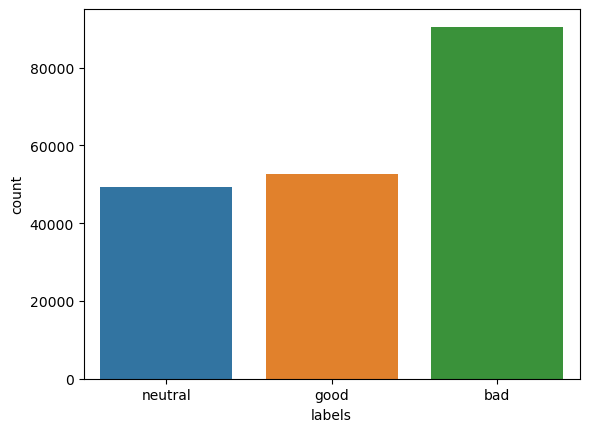

In [18]:
tweets_majority=sns.countplot(data=df, x='labels')
plt.show()
tweets_majority_fig = tweets_majority.get_figure()

In [19]:
target_sample_size = df['labels'].value_counts().min()
df_balanced = pd.DataFrame()  
for label in df['labels'].unique():
    df_temp = df[df['labels'] == label]
    df_resampled = resample(df_temp,
                            replace=False,  # Sample without replacement for undersampling
                            n_samples=10000,  # Match minority class size
                            random_state=123)  # Reproducible results
    df_balanced = pd.concat([df_balanced, df_resampled])

# Check the balanced counts
print(df_balanced['labels'].value_counts())

labels
neutral    10000
good       10000
bad        10000
Name: count, dtype: int64


In [20]:
df_balanced['tweets'].nunique()

30000

In [ ]:
print(df_balanced.duplicated(subset='tweets').sum())

In [ ]:
tweets_majority=sns.countplot(data=df_balanced, x='labels')
plt.show()
tweets_majority_fig = tweets_majority.get_figure()

In [174]:
openai.api_key = 'myKeyHere'

In [627]:
def detect_emotion(text):
    try:
        client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-3.5-turbo-0125", 
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text only as numbers where: good = 1, bad = 2, neutral = 0: {text}"}
            ],
           temperature=0.1, # Setting the temperature here
           top_p = 0.1,
           max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

# Clear asnwer

## First way to solve it

In [196]:
# emotion_mapping = {
#     'neutral': 'neutral',
#     'neutra': 'neutral',
#     'neutral.': 'neutral',
#     'good': 'good',
#     'good.': 'good',
#     'bad': 'bad',
#     'bad.': 'bad',
#     'negative' : 'bad',
#     'positive' : 'good',
# }
#mapped_emotion = emotion_mapping.get(normalized_emotion, 'misc')  # Default to 'misc' if not found
# or 
#mapped_emotion = emotion_mapping.get(normalized_emotion)  # Default to 'misc' if not found
# print(mapped_emotion == None)

## Second way

In [23]:
def normalize_emotion(emotion):
    cleaned_emotion = ''.join([char for char in emotion if char.isalnum()]).lower()
    return cleaned_emotion

In [628]:
def classify_sentiment_by_keyword(normalized_emotion):
    if 'good' in normalized_emotion:
        return 'positive'
    elif 'bad' in normalized_emotion:
        return 'negative'
    elif 'neutral' in normalized_emotion:
        return 'neutral'
    elif 'negative' in normalized_emotion:
        return 'negative'
    elif 'positive' in normalized_emotion:
        return 'negative'
    else:
        # Log unexpected response or handle it as needed
        return normalized_emotion

In [139]:
def classify_sentiment_by_keyword(normalized_emotion):
    if '1' in normalized_emotion:
        return '1'
    elif '2' in normalized_emotion:
        return '2'
    elif '0' in normalized_emotion:
        return '0'
    else:
        return normalized_emotion

# Main Loop

In [147]:
tweets = result_one['tweets']
break_flag = 1000
stop_trigger = 0
dict_test = {
    '0':[],
    '1':[],
    '2':[],
}
let_me_see = {}
for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
    if stop_trigger >= break_flag:
        break
    stop_trigger += 1
    
    emotion = detect_emotion(tweet)
    normalized_emotion = normalize_emotion(emotion)
    last_hope = classify_sentiment_by_keyword(normalized_emotion)

    if last_hope in dict_test:
        dict_test[last_hope].append(tweet)
    else:
        print(f"Received unexpected emotion: {last_hope}")
        if last_hope not in let_me_see:
            let_me_see[last_hope] = []
        let_me_see[last_hope].append((tweet, last_hope))
        if 'misc' not in dict_test:
            dict_test['misc'] = []
        dict_test['misc'].append(tweet)


Chatting with AI:  11%|█         | 108/1000 [01:20<18:55,  1.27s/it]

Received unexpected emotion: imsorrybuticannotprovidesentimentanalysisfortextasnumbersicanonlyprovidesentimentanalysisintermsofgoodbadorneutralifyouhaveaspecifictextyouwouldlikemetoanalyzepleaseprovideitandiwilldomybesttoclassifythesentimentforyou


Chatting with AI:  14%|█▎        | 135/1000 [01:42<15:36,  1.08s/it]

Received unexpected emotion: imsorrybuticannotprovidesentimentanalysisfortextasnumbersicanonlyprovidesentimentanalysisintheformofpositivenegativeorneutralletmeknowifyouwouldlikemetoclassifythesentimentofthetextinthatformat


Chatting with AI:  18%|█▊        | 175/1000 [02:21<14:15,  1.04s/it]

Received unexpected emotion: neutral


Chatting with AI:  22%|██▏       | 219/1000 [02:55<09:08,  1.42it/s]

Received unexpected emotion: neutral


Chatting with AI: 100%|██████████| 1000/1000 [11:30<00:00,  1.45it/s]


## Processing answers

In [149]:
counts_dict = {}
for label, tweets in tqdm(dict_test.items(), desc="Counting tweets", total=len(dict_test)):
    counts_dict[label] = len(tweets)

counts_dict

Counting tweets: 100%|██████████| 4/4 [00:00<00:00, 3997.43it/s]


{'0': 678, '1': 269, '2': 49, 'misc': 4}

In [150]:
data = []
for label, tweets in dict_test.items():
    for tweet in tweets:
        data.append((tweet, label))

In [161]:
df = pd.DataFrame(data, columns=['tweets', 'labels'])
df

,tweets,labels
0,made conclusions nchatgpt help basic keyword r...,0
1,want change school grades results online erase...,0
2,chatgpt glimpse future yes,0
3,would cats good leaders country chatgpt,0
4,chatgpt wild nscanning uses showcased today bl...,0
...,...,...
995,users get chatgpt generate content inappropria...,2
996,use chatgpt ai friend,misc
997,use chatgpt help coding,misc
998,using chatgpt generate stable diffusion text p...,misc


In [ ]:
join_one = pd.merge()

In [180]:
join_one = result_one_all.merge(df, on=['tweets'], how='left', indicator=True)

result_one_all = join_one[join_one['_merge'] == 'both']

result_one_all = result_one_all.drop(columns=['_merge'])

In [197]:
result_one_all['good_promt_parametrs'].unique()

array(['neutral', 'good', 'bad'], dtype=object)

In [199]:
result_one_all

,tweets,target,bad_promt,good_promt,good_promt_parametrs,labels,chat3_number
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral,neutral,neutral,0,neutral
1,learning something way easier chatgpt like dum...,neutral,good,good,good,1,good
2,kinda fun replying bots twitter chatgpt output,neutral,neutral,neutral,neutral,1,good
3,want change school grades results online erase...,neutral,bad,neutral,neutral,0,neutral
4,chatgpt glimpse future yes,neutral,neutral,neutral,neutral,0,neutral
...,...,...,...,...,...,...,...
995,users get chatgpt generate content inappropria...,neutral,neutral,neutral,neutral,2,bad
996,dear writers nchatgpt going end career don mas...,neutral,good,good,good,1,good
997,wife getting creative openai chatgpt,neutral,neutral,neutral,neutral,0,neutral
998,top 10 chatgpt alternatives,neutral,neutral,neutral,neutral,0,neutral


In [227]:
(result_one_all['target'] == result_one_all['chat3_number']).mean()

0.678

In [85]:
save(result_one_all, 'first_data_examples_of_promts')

'first_data_examples_of_promts.csv was saved'

In [80]:
result_one_all.rename(columns ={'pred' : 'bad_promt', 'labels' : 'good_promt_parametrs'},inplace = True)

In [83]:
result_one_all.drop(columns = {'Unnamed: 0'}, inplace = True)

In [84]:
result_one_all

,tweets,target,bad_promt,good_promt,good_promt_parametrs
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral,neutral,neutral
1,learning something way easier chatgpt like dum...,neutral,good,good,good
2,kinda fun replying bots twitter chatgpt output,neutral,neutral,neutral,neutral
3,want change school grades results online erase...,neutral,bad,neutral,neutral
4,chatgpt glimpse future yes,neutral,neutral,neutral,neutral
...,...,...,...,...,...
995,users get chatgpt generate content inappropria...,neutral,neutral,neutral,neutral
996,dear writers nchatgpt going end career don mas...,neutral,good,good,good
997,wife getting creative openai chatgpt,neutral,neutral,neutral,neutral
998,top 10 chatgpt alternatives,neutral,neutral,neutral,neutral


# Corrections

In [870]:
let_me_see

{'unknown': [('chatgpt successors replace google search engine as long don make use technology themselves nyou get specific individual answers instead websites first scroll read through trouble cookies etc also avoided',
   'unknown')]}

In [848]:
df[df['labels'] == 'misc']['tweets']

7672    (chatgpt successors replace google search engi...
Name: tweets, dtype: object

In [849]:
corrections = {}

In [850]:
what = df[df['labels'] == 'misc']['tweets']
for i in what:
    hehe = classify_sentiment_by_keyword(i[1])
    print(i[0], hehe)
    corrections[i[0]] = hehe


chatgpt successors replace google search engine as long don make use technology themselves nyou get specific individual answers instead websites first scroll read through trouble cookies etc also avoided unknown


In [883]:
corrections

{'chatgpt successors replace google search engine as long don make use technology themselves nyou get specific individual answers instead websites first scroll read through trouble cookies etc also avoided': 'unknown'}

In [853]:
df

,tweets,labels
0,algorithmic content curation already better hu...,neutral
1,parental pro tip chatgpt write really good let...,neutral
2,elon musk history chatgpt maker openai told ch...,neutral
3,10 new year resolutions protecting potential r...,neutral
4,big deal chatgpt industries going transformed ...,neutral
...,...,...
7668,chatgpt down nmy life ruin since can appease a...,bad
7669,there something important need know chatgpt bu...,bad
7670,lastpass hacked openai unlocked access chatgpt...,bad
7671,you made one mistake forgot take bullet casing...,bad


In [482]:
df = df.drop(columns = ['Label', 'Tweet'])

In [489]:
df.loc[10640:10651]

,tweets,labels
10640,(imagine wef spending trillions to uh curb ove...,misc
10641,(if chatgpt cut even small percentage time tak...,misc
10642,(google detect essay written chatgpt mark fake...,misc
10643,(exactly happening copywriting bots like chatg...,misc
10644,(chatgpt rare example potential technology tra...,misc
10645,(chatgpt performs par fresh college grad zero ...,misc
10646,(chatgpt housewife requires hustle hard work d...,misc
10647,(overloaded chatgpt feels like dial up interne...,misc
10648,(yes chatgpt politicians spewed vapid drivel e...,misc
10649,(new video on chatgpt discuss unbelievable ai ...,misc


In [493]:
df['labels'].unique()

array(['neutral', 'bad', 'good', 'farright', 'misc'], dtype=object)

In [495]:
df[df['labels'] == 'farright']

,tweets,labels
999,new video on chatgpt discuss unbelievable ai p...,farright


In [331]:
for i,k in corrections.items():
    print(i,k)

made choose adventure goosebumps story using chatgpt interactive im flabbergasted good
ok tonight ll publish gpt experiments past summer nfound really interesting capabilities work chatgpt well neutral
chatgpt soo fucking good could write whole iot essay one promt good
convenient tool pretend got smart chatgpt answer first try good
ok playing chatgpt ve determined ai fact going enslave us bad
find juxtaposition poetry technology humorous nhere chapter poem style walt whitman comparing javascript module bundlers chatgpt neutral
everything typing chatgpt making go holeeee sheeeet write python program draws bouncing boxes screen using pyglet write first page novel main characters details details can sleep neutral
chatgpt interesting field subject really want know that good
metaverse radio web3 near snow indie rap hiphop blockchain nfts crypto gaming coding xr ai gm ar vr art music chatgpt cold metaverseradio n24 365 1st nstay warm all neutral
asked chatgpt artificial intelligence question

In [485]:
correction_list = list(corrections.items())
correction_list

[('imagine wef spending trillions to uh curb overpopulation need half decent realdoll chatgpt collab cut birth rate like 90',
  'bad'),
 ('if chatgpt cut even small percentage time takes marketer complete task we ll see teams flock technology competitive advantage nature jobs change permanently',
  'good'),
 ('google detect essay written chatgpt mark fake always work around like rephrasing whole essay using quillbot teachers going find hard catching smart students',
  'bad'),
 ('exactly happening copywriting bots like chatgpt nmicrosoft putting billions dollars ai suppress conservative voices future ai chatgpt cybersecurity',
  'bad'),
 ('chatgpt rare example potential technology transform world offers glimpse future machines understand respond human language natural intuitive ways expect gpt4',
  'good'),
 ('chatgpt performs par fresh college grad zero experience nas copies template looks kinda right follows familiar structure wow absolute hollow bullshit zero substance',
  'bad'),
 (

In [553]:
df.loc[990:999]

,tweets,labels
990,imagine wef spending trillions to uh curb over...,neutral
991,if chatgpt cut even small percentage time take...,good
992,google detect essay written chatgpt mark fake ...,neutral
993,exactly happening copywriting bots like chatgp...,neutral
994,chatgpt rare example potential technology tran...,neutral
995,chatgpt performs par fresh college grad zero e...,bad
996,chatgpt housewife requires hustle hard work de...,neutral
997,overloaded chatgpt feels like dial up internet,neutral
998,yes chatgpt politicians spewed vapid drivel ev...,neutral
999,new video on chatgpt discuss unbelievable ai p...,good


In [497]:
for i, (text, correct_label) in zip(range(990, 999+1), correction_list):
    df.loc[i, 'labels'] = correct_label
    #df.loc[i, 'tweets'] = text


In [554]:
df['labels'].unique()

array(['neutral', 'good', 'bad'], dtype=object)

In [555]:
df

,tweets,labels
0,like way chatgpt works gotta use endsems,neutral
1,shared,neutral
2,chatgpt shares thoughts enterprise voc program...,neutral
3,here chrome extension gives chatgpt ability se...,neutral
4,rt bcg chatgpt opening world possibilities nbu...,neutral
...,...,...
10647,overloaded chatgpt feels like dial up internet,bad
10648,yes chatgpt politicians spewed vapid drivel ev...,bad
10649,new video on chatgpt discuss unbelievable ai p...,good
10650,ok ll admit even cynical tech curmudgeon chatg...,good


# Save and Laod

In [56]:
def load(name):
    file = pd.read_csv(f'{name}.csv')
    return file

In [55]:
def save(file, name):
    file.to_csv(f'{name}.csv', index = False)
    return f'{name}.csv was saved'

In [585]:
save(result_test, 'chat3_third_dataset3000')

'chat3_third_dataset3000 was saved'

In [936]:
result_df_1.to_csv("last_one_database.csv", index = False)

In [972]:
combined_df_1.to_csv("api_answers_30000.csv", index=False)

In [629]:
# Load a CSV file into a DataFrame
df_test = pd.read_csv('api_answers_12040.csv')

# 40% first_dataset

In [983]:
join_test = combined_df_1.merge(df_balanced, on=['tweets'], how='left', indicator=True)


join_test = join_test.drop(columns=['_merge'])

In [984]:
join_test

,tweets,labels_x,labels_y
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral
1,learning something way easier chatgpt like dum...,neutral,neutral
2,kinda fun replying bots twitter chatgpt output,neutral,neutral
3,want change school grades results online erase...,neutral,neutral
4,chatgpt glimpse future yes,neutral,neutral
...,...,...,...
29995,ai deliver final death blow humanities,bad,bad
29996,breaking chatgpt terrible stop using immediate...,bad,bad
29997,artificial intelligence gives instructions sho...,bad,bad
29998,hackers use chatgpt write malicious phishing e...,bad,bad


In [985]:
join_test = join_test.rename(columns = {'labels_x' : 'predict', 'labels_y' : 'True'})

In [986]:
join_test

,tweets,predict,True
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral
1,learning something way easier chatgpt like dum...,neutral,neutral
2,kinda fun replying bots twitter chatgpt output,neutral,neutral
3,want change school grades results online erase...,neutral,neutral
4,chatgpt glimpse future yes,neutral,neutral
...,...,...,...
29995,ai deliver final death blow humanities,bad,bad
29996,breaking chatgpt terrible stop using immediate...,bad,bad
29997,artificial intelligence gives instructions sho...,bad,bad
29998,hackers use chatgpt write malicious phishing e...,bad,bad


In [987]:
join_test['is_correct'] = join_test['predict'] == join_test['True']

In [988]:
join_test

,tweets,predict,True,is_correct
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral,True
1,learning something way easier chatgpt like dum...,neutral,neutral,True
2,kinda fun replying bots twitter chatgpt output,neutral,neutral,True
3,want change school grades results online erase...,neutral,neutral,True
4,chatgpt glimpse future yes,neutral,neutral,True
...,...,...,...,...
29995,ai deliver final death blow humanities,bad,bad,True
29996,breaking chatgpt terrible stop using immediate...,bad,bad,True
29997,artificial intelligence gives instructions sho...,bad,bad,True
29998,hackers use chatgpt write malicious phishing e...,bad,bad,True


In [990]:
# tylko 40?

In [989]:
accuracy = (join_test['predict'] == join_test['True']).mean()
accuracy

0.40553333333333336

In [821]:
# myslalem ze to jest zly wynik, ale popatrzcie na przyklady

In [993]:

join_test['check'] = 0
join_test

,tweets,predict,True,is_correct,check
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral,True,0
1,learning something way easier chatgpt like dum...,neutral,neutral,True,0
2,kinda fun replying bots twitter chatgpt output,neutral,neutral,True,0
3,want change school grades results online erase...,neutral,neutral,True,0
4,chatgpt glimpse future yes,neutral,neutral,True,0
...,...,...,...,...,...
29995,ai deliver final death blow humanities,bad,bad,True,0
29996,breaking chatgpt terrible stop using immediate...,bad,bad,True,0
29997,artificial intelligence gives instructions sho...,bad,bad,True,0
29998,hackers use chatgpt write malicious phishing e...,bad,bad,True,0


In [1004]:
join_test[join_test['check'] == 1]

,tweets,predict,True,is_correct,check
865,wanted write resignation letter chatgpt me nit...,good,neutral,False,1
866,chatgpt voice could customized answer commands...,good,neutral,False,1
867,most recent chatgpt realization create decent ...,good,neutral,False,1
868,damnn chatgpt soooo amazing quite scary time,good,neutral,False,1
869,teaching chatgpt use command ids effects catch...,good,neutral,False,1
...,...,...,...,...,...
29964,chatgpt ai game changer you re coding scriptin...,good,bad,False,1
29965,chatgpt actually insane nextlevel,good,bad,False,1
29966,made 1300 word story stream beyond riveting us...,good,bad,False,1
29967,chatgpt literally ve always dreamed using goog...,good,bad,False,1


In [1002]:
join_test.loc[join_test['is_correct'] == False, 'check'] = 1

In [1013]:
answer = int(input('What do u thing about it?'))
print(answer)

What do u thing about it? 1


1


In [1033]:
# corrections = {}
tracker = 1

In [1032]:
tweets = join_test[join_test['is_correct'] == False]['tweets']
tweets.iloc[1:]

866      chatgpt voice could customized answer commands...
867      most recent chatgpt realization create decent ...
868           damnn chatgpt soooo amazing quite scary time
869      teaching chatgpt use command ids effects catch...
870                fun chatgpt one jokes absolutely savage
                               ...                        
29964    chatgpt ai game changer you re coding scriptin...
29965                    chatgpt actually insane nextlevel
29966    made 1300 word story stream beyond riveting us...
29967    chatgpt literally ve always dreamed using goog...
29968    chatgpt confirmed it nuclear medicine cooler r...
Name: tweets, Length: 17833, dtype: object

In [1082]:
join_test[join_test['is_correct'] == False]['tweets']

865      wanted write resignation letter chatgpt me nit...
866      chatgpt voice could customized answer commands...
867      most recent chatgpt realization create decent ...
868           damnn chatgpt soooo amazing quite scary time
869      teaching chatgpt use command ids effects catch...
                               ...                        
29964    chatgpt ai game changer you re coding scriptin...
29965                    chatgpt actually insane nextlevel
29966    made 1300 word story stream beyond riveting us...
29967    chatgpt literally ve always dreamed using goog...
29968    chatgpt confirmed it nuclear medicine cooler r...
Name: tweets, Length: 17834, dtype: object

In [1063]:
join_test[join_test['check'] == 2]

,tweets,predict,True,is_correct,check
865,wanted write resignation letter chatgpt me nit...,good,good,False,2
868,damnn chatgpt soooo amazing quite scary time,good,good,False,2


In [1083]:
# 0 - no need to check, 1 to check, 2 cheked and changed, 3 checked and not chenged
stop = 17834
count_to_stop = 0
tweets = join_test[join_test['is_correct'] == False]['tweets']
option = 0
answer = ''
for i in tweets.iloc[tracker:]:
    if count_to_stop >= stop:
        break
        
    count_to_stop += 1
    tracker += 1
    predict = join_test.at[join_test[join_test['tweets'] == i].index[0],'predict']
    true_value = join_test.at[join_test[join_test['tweets'] == i].index[0],'True']
    print('---------------------------------------------------------------------')
    print(f'The sentence is: {i}\nChatGPT says that:{predict.upper()}, meanwhile in dataset answer is:{true_value.upper()}')
    option = int(input('What do u thing about it?\n2 - i need to changed it\n3 - it will be the same\n4 -exit\n5 - hard to say\n'))
    
    if option == 4:
        tracker -= 1
        break
        
    join_test.loc[join_test['tweets'] == i, 'check'] = option
    
    if option == 2:
        answer = input('good, bad or neutral?')
        corrections[i] = [true_value,answer]
        join_test.loc[join_test['tweets'] == i, 'True'] = answer
        if true_value == answer:
            tracker -= 1

---------------------------------------------------------------------
The sentence is: chatgpt user friendly
ChatGPT says that:GOOD, meanwhile in dataset answer is:NEUTRAL


What do u thing about it?
2 - i need to changed it
3 - it will be the same
4 -exit
5 - hard to say
 2
good, bad or neutral? good


---------------------------------------------------------------------
The sentence is: first time using chatgpt yea freaking whoa impressive
ChatGPT says that:GOOD, meanwhile in dataset answer is:NEUTRAL


What do u thing about it?
2 - i need to changed it
3 - it will be the same
4 -exit
5 - hard to say
 2
good, bad or neutral? good


---------------------------------------------------------------------
The sentence is: ve seen chatgpt bot impressively answer complex questions today wife also told got throw error asking what pumpernickel bread
ChatGPT says that:GOOD, meanwhile in dataset answer is:NEUTRAL


...

What do u thing about it?
2 - i need to changed it
3 - it will be the same
4 -exit
5 - hard to say
 2
good, bad or neutral? good


---------------------------------------------------------------------
The sentence is: chatgpt new favorite facebook mom tool
ChatGPT says that:GOOD, meanwhile in dataset answer is:NEUTRAL


What do u thing about it?
2 - i need to changed it
3 - it will be the same
4 -exit
5 - hard to say
 2
good, bad or neutral? good


---------------------------------------------------------------------
The sentence is: extremely simple get chatgpt code like me
ChatGPT says that:GOOD, meanwhile in dataset answer is:NEUTRAL


What do u thing about it?
2 - i need to changed it
3 - it will be the same
4 -exit
5 - hard to say
 4


In [1084]:
tracker

79

In [1066]:
corrections

{'wanted write resignation letter chatgpt me nit made work simple awesome': ['neutral',
  'good'],
 'damnn chatgpt soooo amazing quite scary time': ['neutral', 'good'],
 'stand holding laptop look around me completely satisfied reluctant move on close laptop put away productmanagement chatgpt': ['neutral',
  'good'],
 'chatgpt ridiculously good one example lots seeing paradigm shift practical capability becoming really obvious': ['neutral',
  'good'],
 'chatgpt awesome completed boring assignment using that found usecase': ['neutral',
  'good'],
 'build chatgpt good idea': ['neutral', 'good']}

In [1041]:
dict_saved_as_df = pd.DataFrame.from_dict(corrections)

In [1042]:
dict_saved_as_df

,wanted write resignation letter chatgpt me nit made work simple awesome,damnn chatgpt soooo amazing quite scary time
0,neutral,neutral
1,good,good


In [ ]:
df.to_csv('my_data.csv', index=False)

good


# Second dataset and main

In [18]:
df = pd.read_csv('./text.csv')
df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [1090]:
df['text'].nunique()

393822

In [19]:
df = df.drop_duplicates(subset='text')

In [156]:
df['label'].value_counts()

label
1    135030
0    118511
3     54777
4     43629
2     29468
5     12407
Name: count, dtype: int64

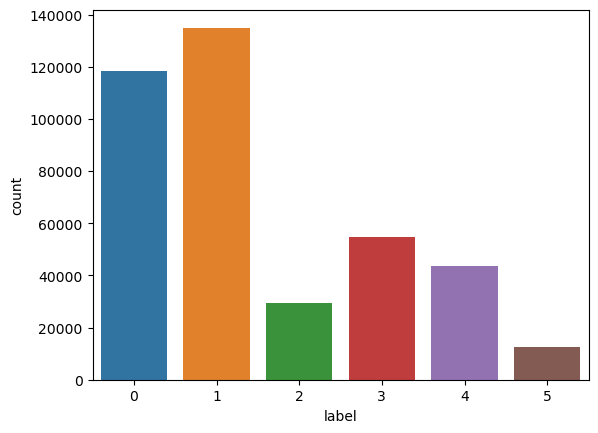

In [159]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
tweets_majority=sns.countplot(data=df, x='label')
plt.show()
tweets_majority_fig = tweets_majority.get_figure()

In [164]:
def Resample(n):
    target_sample_size = df['label'].value_counts().min()
    df_balanced = pd.DataFrame()  
    for label in df['label'].unique():
        df_temp = df[df['label'] == label]
        df_resampled = resample(df_temp,
                                replace=False, 
                                n_samples=n,
                                random_state=123)
        df_balanced = pd.concat([df_balanced, df_resampled])

print(df_balanced['label'].value_counts())

label
4    10000
0    10000
2    10000
1    10000
5    10000
3    10000
Name: count, dtype: int64


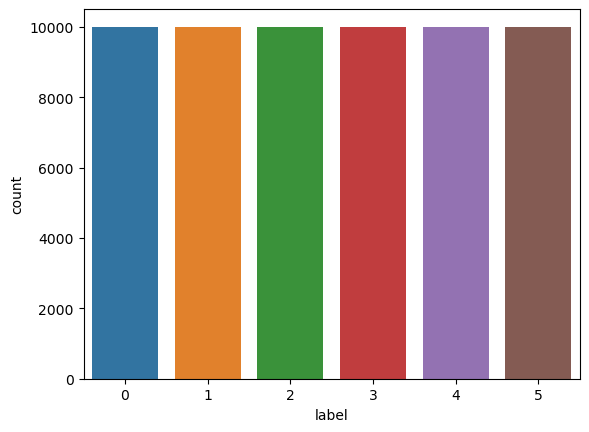

In [165]:
tweets_majority=sns.countplot(data=df_balanced, x='label')
plt.show()
tweets_majority_fig = tweets_majority.get_figure()

In [166]:
df_balanced

,Unnamed: 0,text,label
355239,355239,i work indoors but when i am feeling distresse...,4
61261,61261,i feel restless and grumpy at the same time so...,4
240078,240078,i simply rested but now i feel so agitated tha...,4
403674,403674,i need to pretty much cut wheat out of my diet...,4
123789,123789,my friend had been telling me about a certain ...,4
...,...,...,...
223241,223241,i put an end to that and hold people accountab...,3
407165,407165,i was left home alone feeling angry all over a...,3
141593,141593,i am not trying to hurt or punish anyone i jus...,3
281984,281984,i got back to the gym i mentioned that i was f...,3


In [ ]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)

# Main loops and functions

In [ ]:
def dict_all(dataset, break_point, dict):
    tweets = dataset['text']
    break_flag = break_point
    stop_trigger = 0
    dict_test_new = dict
    let_me_see_new = {}
    for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
        if stop_trigger >= break_flag:
            break
        stop_trigger += 1
        
        emotion = detect_emotion(tweet)
        normalized_emotion = normalize_emotion(emotion)
        last_hope = classify_sentiment_by_keyword_text(normalized_emotion)
    
        if last_hope in dict_test_new:
            dict_test_new[last_hope].append(tweet)
        else:
            print(f"Received unexpected emotion: {last_hope}")
            if last_hope not in let_me_see_new:
                let_me_see_new[last_hope] = []
            let_me_see_new[last_hope].append((tweet, last_hope))
            if 'misc' not in dict_test_new:
                dict_test_new['misc'] = []
            dict_test_new['misc'].append(tweet)
    print('DONE')
    return dict_test_new, let_me_see_new

In [50]:
def detect_emotion_chat4(text):
    try:
        client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-4o", 
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text only as numbers where: 0 = sadness, 1  = joy, 2 = love, 3 = anger, 4 = fear, 5 = surprise: {text}"}
            ],
            temperature=0.1, # Setting the temperature here
            top_p = 0.1,
            max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

In [12]:
def detect_emotion(text):
    try:
        client = OpenAI(
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-3.5-turbo-0125",  #gpt-4o
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text only as: sadness, joy, love, anger, fear, surprise: {text}"}
            ],
            temperature=0.1,
            top_p = 0.1,
            max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

In [732]:
def detect_emotion_3_third_database(text):
    try:
        client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-4o", 
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text only as: neutral, positive, negative. {text}"}
            ],
            temperature=0.1, # Setting the temperature here
            top_p = 0.1,
            max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

In [49]:
def classify_sentiment_by_keyword_text(normalized_emotion):
    if 'sadness' in normalized_emotion:
        return 'sadness'
    elif 'joy' in normalized_emotion:
        return 'joy'
    elif 'love' in normalized_emotion:
        return 'love'
    elif 'anger' in normalized_emotion:
        return 'anger'
    elif 'fear' in normalized_emotion:
        return 'fear'
    elif 'surprise' in normalized_emotion:
        return 'surprise'
    else:
        return normalized_emotion

In [48]:
def classify_sentiment_by_keyword_numbers(normalized_emotion):
    if '0' in normalized_emotion:
        return '0'
    elif '1' in normalized_emotion:
        return '1'
    elif '2' in normalized_emotion:
        return '2'
    elif '3' in normalized_emotion:
        return '3'
    elif '4' in normalized_emotion:
        return '4'
    elif '5' in normalized_emotion:
        return '5'
    else:
        # Log unexpected response or handle it as needed
        return normalized_emotion

In [727]:
def dict_text(dataset, break_point):
    tweets = dataset['text']
    break_flag = break_point
    stop_trigger = 0
    dict_test_new = {
        # '0':[],
        # '1':[],
        # '2':[],
        'positive' : [],
        'negative' : [],
        'neutral' : [],
        # 'sadness':[],
        # 'joy':[],
        # 'love':[],
        # 'anger':[],
        # 'fear':[],
        # 'surprise':[],
    }
    let_me_see_new = {}
    for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
        if stop_trigger >= break_flag:
            break
        stop_trigger += 1
        
        emotion = detect_emotion_3_third_database(tweet)
        normalized_emotion = normalize_emotion(emotion)
        last_hope = classify_sentiment_by_keyword_numbers(normalized_emotion)
    
        if last_hope in dict_test_new:
            dict_test_new[last_hope].append(tweet)
        else:
            print(f"Received unexpected emotion: {last_hope}")
            if last_hope not in let_me_see_new:
                let_me_see_new[last_hope] = []
            let_me_see_new[last_hope].append((tweet, last_hope))
            if 'misc' not in dict_test_new:
                dict_test_new['misc'] = []
            dict_test_new['misc'].append(tweet)
    print('DONE')
    return dict_test_new, let_me_see_new

In [54]:
def dict_numbers(dataset, break_point):
    tweets = dataset['text']
    break_flag = break_point
    stop_trigger = 0
    dict_test_new = {
        '0':[],
        '1':[],
        '2':[],
        '3':[],
        '4':[],
        '5':[],
    }
    let_me_see_new = {}
    for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
        if stop_trigger >= break_flag:
            break
        stop_trigger += 1
        
        emotion = detect_emotion_chat4(tweet)
        normalized_emotion = normalize_emotion(emotion)
        last_hope = classify_sentiment_by_keyword_numbers(normalized_emotion)
    
        if last_hope in dict_test_new:
            dict_test_new[last_hope].append(tweet)
        else:
            print(f"Received unexpected emotion: {last_hope}")
            if last_hope not in let_me_see_new:
                let_me_see_new[last_hope] = []
            let_me_see_new[last_hope].append((tweet, last_hope))
            if 'misc' not in dict_test_new:
                dict_test_new['misc'] = []
            dict_test_new['misc'].append(tweet)
    print('DONE')
    return dict_test_new, let_me_see_new

# data processing


In [534]:
def data_processing(dict_to_processing): 
    counts_dict = {}
    for label, tweets in tqdm(dict_to_processing.items(), desc="Counting tweets", total=len(dict_to_processing)):
        counts_dict[label] = len(tweets)
    
    print(counts_dict)
    data_new = []
    for label, tweets in dict_to_processing.items():
        for tweet in tweets:
            data_new.append((tweet, label))
    
    df_new = pd.DataFrame(data_new, columns=['text', 'labels'])
    return df_new

In [540]:
def data_misc_replace(data_set):
    bruh = []
    for i in data_set[data_set['labels'] == 'misc']['text']:
        bruh.append(i)
    df_misc = pd.DataFrame(bruh, columns=['text'])
    
    data_set.drop(data_set[data_set['labels'] == 'misc'].index, inplace=True)
    combined_df_all = pd.concat([data_set,df_misc])
    combined_df_all.fillna('misc', inplace = True)
    return combined_df_all

In [328]:
df_misc = pd.DataFrame(bruh, columns=['text'])
df_misc

,text
0,i feel like i should just do this instead of g...
1,i understand feeling enthralled by stories lik...
2,i am feeling about it or get curious if it mat...
3,i suggested that she might share her feelings ...
4,i asked feeling more curious than i should
...,...
175,i feel greedy for time alone to work in silence
176,i kind of feel like i should be investing in a...
177,i hope it is because he understands the way i ...
178,i feel selfish if i dont tell you about it


In [336]:
chat_gpt4 = pd.concat([df_old, combined_df_all])
chat_gpt4

,text,labels
0,i work indoors but when i am feeling distresse...,sadness
1,i can honestly say i know at least a little of...,sadness
2,i feel confused hopeless and anxious,sadness
3,i feel helpless to describe my thoughts experi...,sadness
4,i feel a bit distraught upon hearing about the...,sadness
...,...,...
175,i feel greedy for time alone to work in silence,misc
176,i kind of feel like i should be investing in a...,misc
177,i hope it is because he understands the way i ...,misc
178,i feel selfish if i dont tell you about it,misc


# Results of ChatGPT 3.5

In [253]:
result_all_new

,text,labels,chatgpt_3.5_by text,target,chatgpt_3.5,is_correct
0,i work indoors but when i am feeling distresse...,0,sadness,4,0,False
1,i had some rough ideas of what i wanted going ...,0,misc,4,6,False
2,i can honestly say i know at least a little of...,0,sadness,4,0,False
3,i feel confused hopeless and anxious,0,sadness,4,0,False
4,i feel helpless to describe my thoughts experi...,0,fear,4,4,True
...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,misc,misc,3,6,False
59996,i regret that some of our wonderful chinese fr...,misc,sadness,3,0,False
59997,i toate articolele din categoria right america...,misc,anger,3,3,True
59998,the price i was charged for work on my car,misc,anger,3,3,True


In [264]:
result_all_new['labels'] = result_all_new['labels'].replace('misc', 6)

In [265]:
result_all_new['labels'].value_counts()

labels
0    13992
5    13967
3    13804
1     7761
4     6767
2     3611
6       98
Name: count, dtype: int64

In [354]:
mapping = {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5, 'misc': 6}

In [261]:
result_all_new[result_all_new['labels'] == 'misc']

,text,labels,chatgpt_3.5_by text,target,chatgpt_3.5,is_correct
59902,ive been feeling increasingly restless but unf...,misc,sadness,4,0,False
59903,i never feel pressured to have money to look g...,misc,joy,4,1,False
59904,not included on questionnaire,misc,misc,4,6,False
59905,i realise yes there is incredible talent out t...,misc,sadness,4,0,False
59906,i feel like ive hinted at this a couple of tim...,misc,joy,4,1,False
...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,misc,misc,3,6,False
59996,i regret that some of our wonderful chinese fr...,misc,sadness,3,0,False
59997,i toate articolele din categoria right america...,misc,anger,3,3,True
59998,the price i was charged for work on my car,misc,anger,3,3,True


In [356]:
result_all['chatgpt_3.5'] = result_all['chatgpt_3.5_by text'].replace(mapping)
result_all

C:\Users\Acer\AppData\Local\Temp\ipykernel_12472\2035986553.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result_all['chatgpt_3.5'] = result_all['chatgpt_3.5_by text'].replace(mapping)


,text,chatgpt_3.5_by text,target,chatgpt_3.5,is_correct
0,i got the kids up and off to school and then c...,sadness,2,0,False
1,i know however that i cannot control how peopl...,sadness,2,0,False
2,i was feeling a longing so profound it is voic...,sadness,2,0,False
3,im not unhappy for sjs and feeling a little sy...,sadness,2,0,False
4,i decided on days because i still wasnt feelin...,sadness,2,0,False
...,...,...,...,...,...
59995,i see how other could use their money without ...,misc,3,6,False
59996,i am not trying to show off that i do not feel...,misc,3,6,False
59997,i guess the idea is to still feel a little col...,misc,3,6,False
59998,i still have more to go of course and i feel v...,misc,3,6,False


In [181]:
result_all = result_all.rename(columns ={'labels' : 'chatgpt_3.5_by text', 'label': 'target'})
result_all

,text,chatgpt_3.5_by text,target,chatgpt_3.5
0,i got the kids up and off to school and then c...,sadness,2,0
1,i know however that i cannot control how peopl...,sadness,2,0
2,i was feeling a longing so profound it is voic...,sadness,2,0
3,im not unhappy for sjs and feeling a little sy...,sadness,2,0
4,i decided on days because i still wasnt feelin...,sadness,2,0
...,...,...,...,...
59995,i see how other could use their money without ...,misc,3,misc
59996,i am not trying to show off that i do not feel...,misc,3,misc
59997,i guess the idea is to still feel a little col...,misc,3,misc
59998,i still have more to go of course and i feel v...,misc,3,misc


In [357]:
accuracy = (result_all['target'] == result_all['chatgpt_3.5']).mean()
accuracy

0.45936666666666665

In [276]:
result_all_new['is_correct'] = result_all_new['target'] == result_all_new['labels']

In [205]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
a =  result_all[result_all['is_correct'] == False].text
break_flag = 20
stop = 0
for i in result_all[result_all['is_correct'] == False].text:
    
    if break_flag == stop:
        break
    predict = result_all.at[result_all[result_all['text'] == i].index[0],'chatgpt_3.5']
    true_value = result_all.at[result_all[result_all['text'] == i].index[0],'target']
    stop += 1
    print(i, predict, true_value)

i got the kids up and off to school and then came back home and crawled back into bed because i really wasnt feeling too hot 0 2
i know however that i cannot control how people feel about me i am not universally liked to my great chagrin 0 2
i was feeling a longing so profound it is voiceless it dare not speak or rise toward the surface 0 2
im not unhappy for sjs and feeling a little sympathetic towards van 0 2
i decided on days because i still wasnt feeling too hot 0 2
i just wasn t feeling any romantic inklings 0 2
id never really had that feeling of loving anyone 0 2
i feel i am not being loyal no matter how okay with it adam is 0 2
im feeling a little too delicate today to dredge up what new knowledge ive gleaned and share it with the group 0 2
i wont feel loyal towards him anymore 0 2
i didnt feel too hot i was dripping with sweat quite quickly 0 2
im feeling a bit like it was a hot mess epic fail bit of a flail but life goes on 0 2
i don t regret seeing this show but i m really f

In [278]:
result_all_new['is_correct'].value_counts()

is_correct
False    60000
Name: count, dtype: int64

# chatgpt_4 by numbers = 0.5699%

In [22]:
df_main = load('main_dataset')
df_main

,text,labels,target,is_correct,chatgpt_4_text,chatgpt_4,chatgpt_3.5_by text_y,chatgpt_3.5_y
0,i work indoors but when i am feeling distresse...,0,4,False,sadness,0,sadness,0
1,i had some rough ideas of what i wanted going ...,0,4,False,fear,4,misc,6
2,i can honestly say i know at least a little of...,0,4,False,sadness,0,sadness,0
3,i feel confused hopeless and anxious,0,4,False,sadness,0,sadness,0
4,i feel helpless to describe my thoughts experi...,0,4,False,sadness,0,fear,4
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,6,3,False,sadness,0,misc,6
59996,i regret that some of our wonderful chinese fr...,6,3,False,sadness,0,sadness,0
59997,i toate articolele din categoria right america...,6,3,False,anger,3,anger,3
59998,the price i was charged for work on my car,6,3,False,anger,3,anger,3


In [9]:
result_all_chat4 = load('chat4_numbers10000')

In [10]:
accuracy = (result_all_chat4['labels'].astype(str) == result_all_chat4['label'].astype(str)).mean()
print(accuracy)

0.6578


In [40]:
join = df_main.merge(result_all_chat4, on = ['text'], how = 'left', indicator = True)

In [44]:
join_results = join[join['_merge'] == 'left_only']
join_results = join_results.drop(columns=['label', 'labels_y', '_merge'])
join_results

,text,labels_x,target,is_correct,chatgpt_4_text,chatgpt_4,chatgpt_3.5_by text_y,chatgpt_3.5_y
2233,i get to feeling low it also means i dont have...,0,0,False,sadness,0,sadness,0
2234,i feel lousy i havent had one of these in year...,0,0,False,sadness,0,sadness,0
2235,i feel a bit lost at the moment so i m going t...,0,0,False,sadness,0,sadness,0
2236,i feel awful for two days after my cheat day b...,0,0,False,sadness,0,sadness,0
2237,i felt feel so worthless,0,0,False,sadness,0,sadness,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,6,3,False,sadness,0,misc,6
59996,i regret that some of our wonderful chinese fr...,6,3,False,sadness,0,sadness,0
59997,i toate articolele din categoria right america...,6,3,False,anger,3,anger,3
59998,the price i was charged for work on my car,6,3,False,anger,3,anger,3


In [76]:
main_dict, different_emotions = dict_numbers(join_results, 50000)

Chatting with AI:  17%|█▋        | 8725/50000 [1:50:53<10:32:03,  1.09it/s]

Received unexpected emotion: thesentimentoftheprovidedtextisnotclearorspecificenoughtoclassifyitintoanyofthegivencategoriesitappearstobeaneutralstatementwithoutanystrongemotionalindicators


Chatting with AI:  23%|██▎       | 11738/50000 [2:28:56<8:31:32,  1.25it/s] 

Received unexpected emotion: theprovidedtextisincompleteanddoesnotprovideenoughinformationtoaccuratelyclassifythesentimentcouldyoupleaseprovidethecompletetext


Chatting with AI:  53%|█████▎    | 26682/50000 [5:55:11<7:24:43,  1.14s/it] 

...

Received unexpected emotion: itisdifficulttoclassifythesentimentofthetextprovidedasitisincompleteandlackssufficientcontextthetextiwasalreadyfeelingallsupersouthernwithmyahrefhttpwwwdoesnotclearlyconveyanemotionthatfitsintothecategoriesofsadnessjoyloveangerfearorsurprise


Chatting with AI: 100%|█████████▉| 49992/50000 [12:04:28<00:07,  1.00it/s]

Received unexpected emotion: thesentimentofthetextnoresponseisnotclearenoughtoclassifyitintoanyofthegivencategoriesitcouldbeinterpretedinvariouswaysdependingonthecontext


Chatting with AI: 100%|██████████| 50000/50000 [12:04:43<00:00,  1.15it/s]

DONE


In [138]:
df_new = data_processing(main_dict)
df_new

Counting tweets: 100%|██████████| 7/7 [00:00<?, ?it/s]

{'0': 16076, '1': 9894, '2': 6994, '3': 7161, '4': 4314, '5': 5537, 'misc': 24}


In [140]:
combined = data_misc_replace(df_new)

In [149]:
combined_df_chat4_numbers = pd.concat([combined, df_old])

In [161]:
combined_df_chat4_numbers.rename(columns = {'labels': 'chat4_number'}, inplace = True)

In [162]:
combined_df_chat4_numbers

,text,chat4_number
0,i get to feeling low it also means i dont have...,0
1,i feel lousy i havent had one of these in year...,0
2,i feel awful for two days after my cheat day b...,0
3,i felt feel so worthless,0
4,i was feeling very homesick,0
...,...,...
9995,i feel one of those weird moods coming on wher...,5
9996,i think im feeling movement but im still a bit...,5
9997,i place berkeley yahoochat gorgeous drinks ali...,misc
9998,when i was told that my daughter,misc


In [167]:
join_to_main = df_main.merge(combined_df_chat4_numbers, on =['text'], how= 'left')

In [173]:
join_to_main

,text,labels,target,is_correct,chatgpt_4_text,chatgpt_4,chatgpt_3.5_by text_y,chatgpt_3.5_y,chat4_number
0,i work indoors but when i am feeling distresse...,0,4,False,sadness,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,0,4,False,fear,4,misc,6,4
2,i can honestly say i know at least a little of...,0,4,False,sadness,0,sadness,0,0
3,i feel confused hopeless and anxious,0,4,False,sadness,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,0,4,False,sadness,0,fear,4,0
...,...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,6,3,False,sadness,0,misc,6,0
59996,i regret that some of our wonderful chinese fr...,6,3,False,sadness,0,sadness,0,0
59997,i toate articolele din categoria right america...,6,3,False,anger,3,anger,3,4
59998,the price i was charged for work on my car,6,3,False,anger,3,anger,3,3


In [175]:
(join_to_main['chat4_number'].astype(str) == join_to_main['target'].astype(str)).mean()

0.5699666666666666

In [ ]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)

# ChatGPT_4

In [383]:
chat_gpt4

,text,labels
0,i work indoors but when i am feeling distresse...,sadness
1,i can honestly say i know at least a little of...,sadness
2,i feel confused hopeless and anxious,sadness
3,i feel helpless to describe my thoughts experi...,sadness
4,i feel a bit distraught upon hearing about the...,sadness
...,...,...
175,i feel greedy for time alone to work in silence,misc
176,i kind of feel like i should be investing in a...,misc
177,i hope it is because he understands the way i ...,misc
178,i feel selfish if i dont tell you about it,misc


In [386]:
dataset

,text,labels,chatgpt_3.5_by text,target,chatgpt_3.5,is_correct
0,i work indoors but when i am feeling distresse...,0,sadness,4,0,False
1,i had some rough ideas of what i wanted going ...,0,misc,4,6,False
2,i can honestly say i know at least a little of...,0,sadness,4,0,False
3,i feel confused hopeless and anxious,0,sadness,4,0,False
4,i feel helpless to describe my thoughts experi...,0,fear,4,4,False
...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,6,misc,3,6,False
59996,i regret that some of our wonderful chinese fr...,6,sadness,3,0,False
59997,i toate articolele din categoria right america...,6,anger,3,3,False
59998,the price i was charged for work on my car,6,anger,3,3,False


In [388]:
chat_gpt4 = chat_gpt4.rename(columns = {'labels': 'chatgpt_4_text'})

In [390]:
# Assuming df1 is the larger DataFrame with 30,000 samples
# and df2 is the smaller DataFrame with 1,000 samples

# Merge the two DataFrames on the columns of interest with an indicator
# Here, 'how='left' ensures all records from df1 are included
# 'indicator=True' adds a column '_merge' that shows whether the row is from both, left_only, or right_only
# Merge the two DataFrames with an indicator to identify unique rows
join_test_all = dataset.merge(chat_gpt4, on=['text'], how='left', indicator=True)


# Filter rows where '_merge' is 'left_only' which indicates they are only in df1
# Select only the rows that are unique to df1
result_test_all = join_test_all[join_test_4['_merge'] == 'both']

# Drop the merge indicator column as it's no longer needed
result_test_all = result_test_all.drop(columns=['_merge'])

# result_df now contains the data from df1 excluding those found in df2

In [412]:
df_balanced

,Unnamed: 0,text,label
0,355239,i work indoors but when i am feeling distresse...,4
1,61261,i feel restless and grumpy at the same time so...,4
2,240078,i simply rested but now i feel so agitated tha...,4
3,403674,i need to pretty much cut wheat out of my diet...,4
4,123789,my friend had been telling me about a certain ...,4
...,...,...,...
59995,223241,i put an end to that and hold people accountab...,3
59996,407165,i was left home alone feeling angry all over a...,3
59997,141593,i am not trying to hurt or punish anyone i jus...,3
59998,281984,i got back to the gym i mentioned that i was f...,3


In [408]:
df_balanced = df_balanced.reset_index(drop=True)

In [413]:
df_balanced

,Unnamed: 0,text,label
0,355239,i work indoors but when i am feeling distresse...,4
1,61261,i feel restless and grumpy at the same time so...,4
2,240078,i simply rested but now i feel so agitated tha...,4
3,403674,i need to pretty much cut wheat out of my diet...,4
4,123789,my friend had been telling me about a certain ...,4
...,...,...,...
59995,223241,i put an end to that and hold people accountab...,3
59996,407165,i was left home alone feeling angry all over a...,3
59997,141593,i am not trying to hurt or punish anyone i jus...,3
59998,281984,i got back to the gym i mentioned that i was f...,3


# compare columns

In [598]:
join_to_main =load('main_dataset_with_answers')

In [179]:
save(join_to_main, 'main_dataset_with_answers')

'main_dataset_with_answers.csv was saved'

In [599]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
join_to_main

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3


In [124]:
(join_to_main['target'] == join_to_main['chat3']).mean()

0.45936666666666665

In [125]:
(join_to_main['target'] == join_to_main['chat3_number']).mean()

0.4841666666666667

In [126]:
(join_to_main['target'] == join_to_main['chat4']).mean()

0.5312833333333333

In [128]:
(join_to_main['target'].astype(str) == join_to_main['chat4_number'].astype(str)).mean()

0.5699666666666666

In [203]:
join_to_main

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3


In [428]:
random_samples = join_to_main.sample(n=1000)

In [429]:
(random_samples['target'].astype(str) == random_samples['chat4_number'].astype(str)).mean()

0.552

In [430]:
(random_samples['target'].astype(str) == random_samples['chat4'].astype(str)).mean()

0.535

In [431]:
(random_samples['target'].astype(str) == random_samples['chat3'].astype(str)).mean()

0.485

In [432]:
(random_samples['target'].astype(str) == random_samples['chat3_number'].astype(str)).mean()

0.501

In [ ]:
random_samples['chat4_text'].replace

## chat4

In [257]:
join_to_main['chatgpt_4'].value_counts(normalize = True).mul(100).round(2)

chatgpt_4
0    32.88
1    20.46
4    13.59
3    13.22
2     9.42
5     8.69
6     1.75
Name: proportion, dtype: float64

In [258]:
join_to_main['chat4_number'].value_counts(normalize = True).mul(100).round(2)

chat4_number
0       29.66
4       18.15
1       17.40
3       12.71
2       12.36
5        9.68
misc     0.04
Name: proportion, dtype: float64

In [176]:
(join_to_main['chatgpt_4'].astype(str) == join_to_main['target'].astype(str)).mean()

0.5312833333333333

In [178]:
(join_to_main['chat4_number'].astype(str) == join_to_main['target'].astype(str)).mean()

0.5699666666666666

In [180]:
(join_to_main['chatgpt_4'].astype(str) != join_to_main['chat4_number'].astype(str)).mean()

0.8185166666666667

In [ ]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)

In [199]:
for i in join_to_main[join_to_main['chatgpt_4'].astype(str) != join_to_main['chat4_number'].astype(str)]['text']:
    chat_emotions = join_to_main[join_to_main['text'] == i]['chatgpt_4'].values[0]
    chat_numbers = join_to_main[join_to_main['text'] == i]['chat4_number'].values[0]
    chat_target = join_to_main[join_to_main['text'] == i]['target'].values[0]
    print(i, f'Emotion: {chat_emotions} -------- Number: {chat_numbers} -------- Target: {chat_target}')
    x = input('______')
    if x == 'exit':
        break

i feel confused hopeless and anxious Emotion: 0 -------- Number: 4 -------- Target: 4


______ 


i do feel for all those people whose homes are threatened by floodwater at this time and hope that you are all safe and well Emotion: 0 -------- Number: 2 -------- Target: 4


______ 


i feel vulnerable i return to the present because it is here that life is lived Emotion: 0 -------- Number: 4 -------- Target: 4


...

______ 


i feel insecure and it shows rel bookmark permalink Emotion: 0 -------- Number: 4 -------- Target: 4


______ 


i moved to this neighborhood in july and had just started to get my bearings and now i m feeling pretty shaky again says washington university senior sienna malik Emotion: 0 -------- Number: 4 -------- Target: 4


______ exit


In [220]:
join_to_main[(join_to_main['chatgpt_4'].astype(str)!= join_to_main['chat4_number'].astype(str)) & (join_to_main['chat4_number'].astype(str) == join_to_main['target'].astype(str))]['text'].nunique()

4729

In [276]:
join_to_main[(join_to_main['chat4'].astype(str)!= join_to_main['chat4_number'].astype(str)) & (join_to_main['chat4'].astype(str) == join_to_main['target'].astype(str))]['text'].nunique()

2408

In [219]:
join_to_main[(join_to_main['chatgpt_4'].astype(str) != join_to_main['chat4_number'].astype(str))]['text'].nunique()

10889

## chat3

### chat3_first_dataset

In [86]:
result_one_all

,tweets,target,bad_promt,good_promt,good_promt_parametrs
0,made conclusions nchatgpt help basic keyword r...,neutral,neutral,neutral,neutral
1,learning something way easier chatgpt like dum...,neutral,good,good,good
2,kinda fun replying bots twitter chatgpt output,neutral,neutral,neutral,neutral
3,want change school grades results online erase...,neutral,bad,neutral,neutral
4,chatgpt glimpse future yes,neutral,neutral,neutral,neutral
...,...,...,...,...,...
995,users get chatgpt generate content inappropria...,neutral,neutral,neutral,neutral
996,dear writers nchatgpt going end career don mas...,neutral,good,good,good
997,wife getting creative openai chatgpt,neutral,neutral,neutral,neutral
998,top 10 chatgpt alternatives,neutral,neutral,neutral,neutral


In [89]:
print('Dobry promt z parametrami', (result_one_all['target'] == result_one_all['good_promt_parametrs']).mean(),
      '\nDobry promt bez parametrów: ', (result_one_all['target'] == result_one_all['good_promt']).mean(),
      '\nZły promt bez parametrów', (result_one_all['target'] == result_one_all['bad_promt']).mean())

Dobry promt z parametrami 0.817 
Dobry promt bez parametrów:  0.814 
Zły promt bez parametrów 0.707


### second data set

In [274]:
join_to_main

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3


In [237]:
join_to_main.rename(columns = {'chatgpt_3.5_y' : 'chat3', 'labels' : 'chat3_number', 'chatgpt_3.5_by text_y' : 'chat3_text', 'chatgpt_4_text': 'chat4_text'},inplace = True)
join_to_main.drop(columns = ['is_correct'], inplace = True)

In [244]:
join_to_main = join_to_main.reindex(columns=['text', 'target', 'chat3_text', 'chat3', 'chat3_number', 'chat4_text', 'chatgpt_4', 'chat4_number'])
join_to_main

,text,target,chat3_text,chat3,chat3_number,chat4_text,chatgpt_4,chat4_number
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3


In [262]:
(join_to_main['chat3_number'] == join_to_main['target']).mean()

0.4841666666666667

In [263]:
(join_to_main['target'] == join_to_main['chat3']).mean()

0.45936666666666665

In [264]:
join_to_main['chat3_number'].value_counts(normalize = True).mul(100).round(2)

chat3_number
0    23.32
5    23.28
3    23.01
1    12.93
4    11.28
2     6.02
6     0.16
Name: proportion, dtype: float64

In [265]:
join_to_main['chat3'].value_counts(normalize = True).mul(100).round(2)

chat3
0    36.39
1    29.44
4    11.90
3     9.17
2     5.72
5     5.72
6     1.65
Name: proportion, dtype: float64

In [289]:
# porownac wyniki od inncyh uzytkownikach,na tej samej bazie, ile wyrazow w zdaniu + literatura

15280

In [285]:
((join_to_main['chat3'].astype(str) != join_to_main['chat3_number'].astype(str)) == join_to_main['target']).value_counts()

False    48870
True     11130
Name: count, dtype: int64

In [266]:
join_to_main[(join_to_main['chat3'].astype(str) != join_to_main['chat3_number'].astype(str))]['text'].nunique()

24961

In [267]:
join_to_main[(join_to_main['chat3'].astype(str)!= join_to_main['chat3_number'].astype(str)) & (join_to_main['chat3_number'].astype(str) == join_to_main['target'].astype(str))]['text'].nunique()

8384

In [269]:
join_to_main[(join_to_main['chat3'].astype(str)!= join_to_main['chat3_number'].astype(str)) & (join_to_main['chat3'].astype(str) == join_to_main['target'].astype(str))]['text'].nunique()

6896

In [296]:
from sklearn.metrics import accuracy_score, f1_score

In [297]:
chat3_accuracy = accuracy_score(join_to_main['target'].astype(str), join_to_main['chat3'].astype(str))
chat3_number_accuracy = accuracy_score(join_to_main['target'].astype(str), join_to_main['chat3_number'].astype(str))

chat3_f1 = f1_score(join_to_main['target'].astype(str), join_to_main['chat3'].astype(str), average='macro')
chat3_number_f1 = f1_score(join_to_main['target'].astype(str), join_to_main['chat3_number'].astype(str), average='macro')

print(f"Chat3 Accuracy: {chat3_accuracy:.3f}, F1-score: {chat3_f1:.3f}")
print(f"Chat3 Number Accuracy: {chat3_number_accuracy:.3f}, F1-score: {chat3_number_f1:.3f}")

Chat3 Accuracy: 0.459, F1-score: 0.385
Chat3 Number Accuracy: 0.484, F1-score: 0.406


In [302]:
from sklearn.metrics import precision_score, recall_score

# Define the true labels (target column)
y_true = join_to_main['target'].astype(str)

# Define the predicted labels for chat3 and chat3_number columns
y_pred_chat3 = join_to_main['chat3'].astype(str)
y_pred_chat3_number = join_to_main['chat3_number'].astype(str)

# Calculate precision and recall for chat3 column
precision_chat3 = precision_score(y_true, y_pred_chat3, average='macro', zero_division=0)
recall_chat3 = recall_score(y_true, y_pred_chat3, average='macro', zero_division=0)

print(f"Chat3 Precision: {precision_chat3:.3f}, Recall: {recall_chat3:.3f}")

# Calculate precision and recall for chat3_number column
precision_chat3_number = precision_score(y_true, y_pred_chat3_number, average='macro', zero_division=0)
recall_chat3_number = recall_score(y_true, y_pred_chat3_number, average='macro', zero_division=0)

print(f"Chat3 Number Precision: {precision_chat3_number:.3f}, Recall: {recall_chat3_number:.3f}")

Chat3 Precision: 0.488, Recall: 0.394
Chat3 Number Precision: 0.443, Recall: 0.415


In [307]:
print(f"Chat3            Accuracy: {chat3_accuracy:.3f}, Precision: {precision_chat3:.3f}, Recall: {recall_chat3:.3f}, F1-score: {chat3_f1:.3f}")
print(f"Chat3_Number     Accuracy: {chat3_number_accuracy:.3f}, Precision: {precision_chat3_number:.3f}, Recall: {recall_chat3_number:.3f}, F1-score: {chat3_number_f1:.3f}")
#print(f"Chat3 Accuracy: {chat3_accuracy:.3f}, F1-score: {chat3_f1:.3f}")
# print(f"Chat3 Number , ")

Chat3            Accuracy: 0.459, Precision: 0.488, Recall: 0.394, F1-score: 0.385
Chat3_Number     Accuracy: 0.484, Precision: 0.443, Recall: 0.415, F1-score: 0.406


# ThirdDataSet

In [308]:
df = pd.read_csv('Tweets.csv')

In [309]:
df = df.drop(columns = {'textID'})

In [310]:
df['sentiment'].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [311]:
df['text']

0                      I`d have responded, if I were going
1            Sooo SAD I will miss you here in San Diego!!!
2                                my boss is bullying me...
3                           what interview! leave me alone
4         Sons of ****, why couldn`t they put them on t...
                               ...                        
27476     wish we could come see u on Denver  husband l...
27477     I`ve wondered about rake to.  The client has ...
27478     Yay good for both of you. Enjoy the break - y...
27479                           But it was worth it  ****.
27480       All this flirting going on - The ATG smiles...
Name: text, Length: 27481, dtype: object

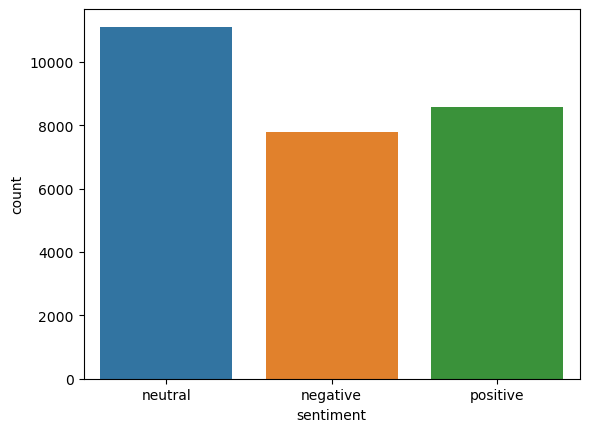

In [312]:
tweets_majority=sns.countplot(data=df, x='sentiment')
plt.show()
tweets_majority_fig = tweets_majority.get_figure()

In [313]:
target_sample_size = df['sentiment'].value_counts().min()
df_balanced_1 = pd.DataFrame()  
for label in df['sentiment'].unique():
    df_temp = df[df['sentiment'] == label]
    df_resampled = resample(df_temp,
                            replace=False,  # Sample without replacement for undersampling
                            n_samples=7500,  # Match minority class size
                            random_state=123)  # Reproducible results
    df_balanced_1 = pd.concat([df_balanced_1, df_resampled])

# Check the balanced counts
print(df_balanced_1['sentiment'].value_counts())

sentiment
neutral     7500
negative    7500
positive    7500
Name: count, dtype: int64


In [247]:
df_old = load('chat3_third_dataset3000')
df_new_by_text = load('third_dataset_19500_text_chat3')
df_new_by_numbers = load('third_dataset_19500_text_chat4(to_replace)')

In [259]:
dataset_3 = load('Tweets')

In [593]:
a = load('3dataset_full')
a

,text,chat3,selected_text,target,chat4,chat3_nubmer
0,home from school today,neutral,home from school today,neutral,neutral,0
1,_teamgreen Marriage course is not running on e...,neutral,Marriage course is not running on either of th...,neutral,positive,0
2,now if I still lived that way you could pop i...,neutral,now if I still lived that way you could pop in...,neutral,negative,0
3,Listening to Lady Gaga... Relatives just left ...,neutral,Listening to Lady Gaga... Relatives just left ...,neutral,positive,0
4,your understanding would require taking parag...,neutral,your understanding would require taking paragr...,neutral,positive,0
...,...,...,...,...,...,...
22494,just come in from the garden. It is very warm ...,neutral,beautiful.,positive,positive,1
22495,happy birthday to my little sister gee! in cel...,positive,happy,positive,positive,1
22496,_d he`s a lucky baby. He has a wonderful famil...,positive,he`s a lucky baby.,positive,positive,1
22497,because he _real_nash wants to be an honorary ...,positive,thanks,positive,positive,1


In [597]:
save(join_it, '3dataset_full')

'3dataset_full.csv was saved'

In [360]:
(result_huh['target'] == result_huh['chat3']).mean()

0.6818969731988088

In [402]:
(result_huh['target'] == result_huh['chat4']).mean()

0.6001600071114271

In [530]:
result_huh

,text,chat3,selected_text,target,chat4
0,home from school today,neutral,home from school today,neutral,neutral
1,_teamgreen Marriage course is not running on e...,neutral,Marriage course is not running on either of th...,neutral,positive
2,now if I still lived that way you could pop i...,neutral,now if I still lived that way you could pop in...,neutral,negative
3,Listening to Lady Gaga... Relatives just left ...,neutral,Listening to Lady Gaga... Relatives just left ...,neutral,positive
4,your understanding would require taking parag...,neutral,your understanding would require taking paragr...,neutral,positive
...,...,...,...,...,...
22494,just come in from the garden. It is very warm ...,neutral,beautiful.,positive,positive
22495,happy birthday to my little sister gee! in cel...,positive,happy,positive,positive
22496,_d he`s a lucky baby. He has a wonderful famil...,positive,he`s a lucky baby.,positive,positive
22497,because he _real_nash wants to be an honorary ...,positive,thanks,positive,positive


In [415]:
random_samples = result_huh.sample(n=1000)

In [416]:
(random_samples['target'] == random_samples['chat4']).mean()

0.567

In [417]:
(random_samples['target'] == random_samples['chat3']).mean()

0.645

In [734]:
def classify_sentiment_by_keyword_numbers(normalized_emotion):
    if 'positive' in normalized_emotion:
        return 'positive'
    elif 'negative' in normalized_emotion:
        return 'negative'
    elif 'neutral' in normalized_emotion:
        return 'neutral'
    else:
        # Log unexpected response or handle it as needed
        return normalized_emotion

In [584]:
def dict_numbers(dataset, break_point):
    tweets = dataset['text']
    stop_trigger = 0
    dict_test_new = {
        'positive' : [],
        'negative' : [],
        'neutral' : [],
    }
    let_me_see_new = {}
    for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_point):
        if stop_trigger >= break_point:
            break
        stop_trigger += 1
        
        emotion = detect_emotion_3_third_database(tweet)
        normalized_emotion = normalize_emotion(emotion)
        last_hope = classify_sentiment_by_keyword_numbers(normalized_emotion)
    
        if last_hope in dict_test_new:
            dict_test_new[last_hope].append(tweet)
        else:
            print(f"Received unexpected emotion: {last_hope}")
            if last_hope not in let_me_see_new:
                let_me_see_new[last_hope] = []
            let_me_see_new[last_hope].append((tweet, last_hope))
            if 'misc' not in dict_test_new:
                dict_test_new['misc'] = []
            dict_test_new['misc'].append(tweet)
    print('DONE')
    return dict_test_new, let_me_see_new

In [585]:
dict_test_new, let_me_see_new = dict_numbers(result_huh,22499)

Chatting with AI:   2%|▏         | 409/22499 [04:59<4:08:57,  1.48it/s] 

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI:   8%|▊         | 1876/22499 [21:33<3:54:30,  1.47it/s] 

Received unexpected emotion: imsorrybuticantclassifythesentimentofthetextwithoutseeingtheactualtextcouldyoupleaseprovidethetextyouwouldlikemetoanalyze


Chatting with AI:  11%|█         | 2441/22499 [27:47<29:11:06,  5.24s/it]

...

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI:  98%|█████████▊| 22117/22499 [3:47:21<03:52,  1.65it/s]  

Received unexpected emotion: iwouldbehappytohelppleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI: 100%|██████████| 22499/22499 [3:50:43<00:00,  1.63it/s]

DONE


In [549]:
3012 + 11920 + 7563 + 4

22499

In [733]:
do_it = data_processing(dict_test_new)

Counting tweets: 100%|██████████| 4/4 [00:00<?, ?it/s]


{'positive': 4889, 'negative': 5080, 'neutral': 5029, 'misc': 2}


In [587]:
do_it_misc = data_misc_replace(do_it)

In [588]:
do_it_misc

,text,labels
0,home from school today,0
1,_teamgreen Marriage course is not running on e...,0
2,"ok, i`m actually going to sleep now =] i`ve be...",0
3,Woke up at 8:30am....now 10:30am and no clue w...,0
4,just got up and updated my ipod,0
...,...,...
4,thanks,misc
5,http://bit.ly/5pBLz for McCoy`s initial rant.,misc
6,please?,misc
7,?,misc


In [572]:
result_huh

,text,chat3,selected_text,target,chat4
0,home from school today,neutral,home from school today,neutral,neutral
1,_teamgreen Marriage course is not running on e...,neutral,Marriage course is not running on either of th...,neutral,positive
2,now if I still lived that way you could pop i...,neutral,now if I still lived that way you could pop in...,neutral,negative
3,Listening to Lady Gaga... Relatives just left ...,neutral,Listening to Lady Gaga... Relatives just left ...,neutral,positive
4,your understanding would require taking parag...,neutral,your understanding would require taking paragr...,neutral,positive
...,...,...,...,...,...
22494,just come in from the garden. It is very warm ...,neutral,beautiful.,positive,positive
22495,happy birthday to my little sister gee! in cel...,positive,happy,positive,positive
22496,_d he`s a lucky baby. He has a wonderful famil...,positive,he`s a lucky baby.,positive,positive
22497,because he _real_nash wants to be an honorary ...,positive,thanks,positive,positive


In [589]:
join_it = result_huh.merge(do_it_misc, on = 'text', how = 'left')

In [596]:
join_it

,text,chat3,selected_text,target,chat4,chat3_nubmer,chat4_nubmer
0,home from school today,neutral,home from school today,neutral,neutral,0,0
1,_teamgreen Marriage course is not running on e...,neutral,Marriage course is not running on either of th...,neutral,positive,0,0
2,now if I still lived that way you could pop i...,neutral,now if I still lived that way you could pop in...,neutral,negative,0,2
3,Listening to Lady Gaga... Relatives just left ...,neutral,Listening to Lady Gaga... Relatives just left ...,neutral,positive,0,1
4,your understanding would require taking parag...,neutral,your understanding would require taking paragr...,neutral,positive,0,2
...,...,...,...,...,...,...,...
22494,just come in from the garden. It is very warm ...,neutral,beautiful.,positive,positive,1,1
22495,happy birthday to my little sister gee! in cel...,positive,happy,positive,positive,1,1
22496,_d he`s a lucky baby. He has a wonderful famil...,positive,he`s a lucky baby.,positive,positive,1,1
22497,because he _real_nash wants to be an honorary ...,positive,thanks,positive,positive,1,1


In [594]:
join_it = a.merge(do_it_misc, on = 'text', how = 'left')
join_it

,text,chat3,selected_text,target,chat4,chat3_nubmer,labels
0,home from school today,neutral,home from school today,neutral,neutral,0,0
1,_teamgreen Marriage course is not running on e...,neutral,Marriage course is not running on either of th...,neutral,positive,0,0
2,now if I still lived that way you could pop i...,neutral,now if I still lived that way you could pop in...,neutral,negative,0,2
3,Listening to Lady Gaga... Relatives just left ...,neutral,Listening to Lady Gaga... Relatives just left ...,neutral,positive,0,1
4,your understanding would require taking parag...,neutral,your understanding would require taking paragr...,neutral,positive,0,2
...,...,...,...,...,...,...,...
22494,just come in from the garden. It is very warm ...,neutral,beautiful.,positive,positive,1,1
22495,happy birthday to my little sister gee! in cel...,positive,happy,positive,positive,1,1
22496,_d he`s a lucky baby. He has a wonderful famil...,positive,he`s a lucky baby.,positive,positive,1,1
22497,because he _real_nash wants to be an honorary ...,positive,thanks,positive,positive,1,1


In [595]:
join_it.rename(columns = {'labels': 'chat4_nubmer'}, inplace = True)

## chat3 0.672

In [379]:
def detect_emotion(text):
    try:
        client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-4o", 
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text as: negative, neutral, positive: {text}"}
            ],
            temperature=0.1, # Setting the temperature here
            top_p = 0.1,
            max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

In [380]:
def classify_sentiment_by_keyword(normalized_emotion):
    if 'positive' in normalized_emotion:
        return 'positive'
    elif 'negative' in normalized_emotion:
        return 'negative'
    elif 'neutral' in normalized_emotion:
        return 'neutral'
    else:
        # Log unexpected response or handle it as needed
        return normalized_emotion

In [401]:
huh[huh['text'] == 'Eating ice cream at swensens']

,text,selected_text,sentiment
1028,Eating ice cream at swensens,Eating ice cream at swensens,neutral


In [382]:
tweets = huh['text']
break_flag = 19500
stop_trigger = 0
dict_test_new = {
    'neutral':[],
    'positive':[],
    'negative':[],
}
let_me_see_new = {}
for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
    if stop_trigger >= break_flag:
        break
    stop_trigger += 1
    
    emotion = detect_emotion(tweet)
    normalized_emotion = normalize_emotion(emotion)
    last_hope = classify_sentiment_by_keyword(normalized_emotion)

    if last_hope in dict_test_new:
        dict_test_new[last_hope].append(tweet)
    else:
        print(f"Received unexpected emotion: {last_hope}")
        if last_hope not in let_me_see_new:
            let_me_see_new[last_hope] = []
        let_me_see_new[last_hope].append((tweet, last_hope))
        if 'misc' not in dict_test_new:
            dict_test_new['misc'] = []
        dict_test_new['misc'].append(tweet)
print('DONE')

Chatting with AI:   9%|▊         | 1695/19500 [37:24<6:48:11,  1.38s/it] 

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassifyandiwillanalyzeitssentimentforyou


Chatting with AI:  22%|██▏       | 4216/19500 [1:34:40<4:48:34,  1.13s/it] 

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI:  24%|██▎       | 4589/19500 [1:43:15<5:34:22,  1.35s/it] 

Received unexpected emotion: thetextprovidedisnotinenglishandcontainsamixofcharactersthatmaynotformcoherentwordsorsentenceswithoutaclearunderstandingofthelanguageandcontextitischallengingtoaccuratelyclassifythesentimentifyoucanprovideatranslationormorecontextiwouldbehappytohelpwiththesentimentanalysis


Chatting with AI:  77%|███████▋  | 15007/19500 [5:30:18<1:38:45,  1.32s/it] 

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI: 100%|██████████| 19500/19500 [7:08:32<00:00,  1.32s/it]  

DONE


In [392]:
data_ = []
for label, tweets in dict_test_new.items():
    for tweet in tweets:
        data_.append((tweet, label))

In [393]:
df_add = pd.DataFrame(data_, columns=['text', 'sentiment'])
df_add

,text,sentiment
0,home from school today,neutral
1,just got up and updated my ipod,neutral
2,Eating ice cream at swensens,neutral
3,hasn`t shipped yet I won`t get over there un...,neutral
4,_Tech_Update Do you know your Nutty Newsire tw...,neutral
...,...,...
19495,pulled from interesting meeting to an urgent s...,negative
19496,why do you think so?,misc
19497,Why?,misc
19498,_nobel ? ? ????????????? = ?????? ?????? ????...,misc


In [402]:
bruh

[' why do you think so?',
 ' Why?',
 '_nobel ? ? ?????????????  = ?????? ?????? ?????? ?? ????',
 'please?']

In [385]:
bruh = []
for i in df_add[df_add['sentiment'] == 'misc']['text']:
    bruh.append(i)
df_misc = pd.DataFrame(bruh, columns=['text'])
df_misc
df_add.drop(df_add[df_add['sentiment'] == 'misc'].index, inplace=True)

In [386]:
combined_df_new = pd.concat([df_add,df_misc])
combined_df_new.fillna('misc', inplace = True)

In [403]:
combined_df_new

,text,sentiment
0,home from school today,neutral
1,just got up and updated my ipod,neutral
2,Eating ice cream at swensens,neutral
3,hasn`t shipped yet I won`t get over there un...,neutral
4,_Tech_Update Do you know your Nutty Newsire tw...,neutral
...,...,...
19495,pulled from interesting meeting to an urgent s...,negative
0,why do you think so?,misc
1,Why?,misc
2,_nobel ? ? ????????????? = ?????? ?????? ????...,misc


In [404]:
save(combined_df_new, 'third_dataset_19500_text_chat4(to_replace)')

'third_dataset_19500_text_chat4(to_replace).csv was saved'

In [568]:
join_test = df_balanced_1.merge(combined_df_new, on=['text'], how='left', indicator=True)

result_test = join_test[join_test['_merge'] == 'both']

result_test = result_test.drop(columns=['_merge'])

In [570]:
(result_test['sentiment_x'] == result_test['sentiment_y']).mean()  

0.672

In [573]:
result_test['equal'] = result_test['sentiment_x'] == result_test['sentiment_y']
result_test[result_test['equal'] == False]

,text,selected_text,sentiment_x,sentiment_y,equal
1,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,neutral,negative,False
2,Hence the smiley face. ha ha ha ha. Lol yeah ...,Hence the smiley face. ha ha ha ha. Lol yeah ...,neutral,positive,False
4,I will try. But I don`t care what my mum says,I will try. But I don`t care what my mum says,neutral,negative,False
8,And it`s such glorious weather too - poor you,And it`s such glorious weather too - poor you,neutral,positive,False
9,She lives! You were so Twitter quiet after t...,She lives! You were so Twitter quiet after th...,neutral,positive,False
...,...,...,...,...,...
2958,hearing the birds chirp makes me think its nic...,nice outside..,positive,negative,False
2970,I`ve thought about it several times . got a f...,good,positive,neutral,False
2983,try having your best writing five years behin...,best writing five years,positive,neutral,False
2990,"@ all mothers, Happy Mother`s Day, at all non-...","Happy Mother`s Day, at all non-mothers, Happy ...",positive,neutral,False


In [555]:
df_balanced_1[df_balanced_1['text'] == ' What you said about aj made no sense,hahaha. What were you talking about? And I loved that picture of you and colin!']

,text,selected_text,sentiment
3108,"What you said about aj made no sense,hahaha. ...",loved,positive


## Chat4 0.601

In [578]:
def detect_emotion(text):
    try:
        client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("myKeyHere"),
        )
    
        chat_completion = client.chat.completions.create(
            model="gpt-4o", 
            messages=[
                {"role": "user", "content": f"Classify the sentiment of the following text as: negative,  neutral, positive: {text}"}
            ],
            temperature=0.1, # Setting the temperature here
            top_p = 0.1,
            max_tokens=256
        )
        # Assuming the response contains the emotion or sentiment as the output
        emotion = chat_completion.choices[0].message.content
        return emotion
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None

In [599]:
tweets = work_with_third['text']
break_flag = 3000
stop_trigger = 0
dict_test_new = {
    'neutral':[],
    'positive':[],
    'negative':[],
}
let_me_see_new = {}
for tweet in tqdm(tweets, desc = "Chatting with AI", total = break_flag):
    if stop_trigger >= break_flag:
        break
    stop_trigger += 1
    
    emotion = detect_emotion(tweet)
    normalized_emotion = normalize_emotion(emotion)
    last_hope = classify_sentiment_by_keyword(normalized_emotion)

    if last_hope in dict_test_new:
        dict_test_new[last_hope].append(tweet)
    else:
        print(f"Received unexpected emotion: {last_hope}")
        if last_hope not in let_me_see_new:
            let_me_see_new[last_hope] = []
        let_me_see_new[last_hope].append((tweet, last_hope))
        if 'misc' not in dict_test_new:
            dict_test_new['misc'] = []
        dict_test_new['misc'].append(tweet, last_hope)
print('DONE')

Chatting with AI: 100%|██████████| 3000/3000 [1:00:42<00:00,  1.21s/it]

DONE


In [600]:
data_ = []
for label, tweets in dict_test_new.items():
    for tweet in tweets:
        data_.append((tweet, label))

In [601]:
df_add = pd.DataFrame(data_, columns=['text', 'sentiment'])
df_add

,text,sentiment
0,Not yet. I hope to check it out this week.,neutral
1,I already did..,neutral
2,"just finished some Sunday cleaning, waiting to...",neutral
3,back from driving and now back to bed,neutral
4,dedicating the next 2 hours to cleaning the house,neutral
...,...,...
2995,Have fun amorsote even tho u forgot my bday,negative
2996,boooo on life decisions....bottle of wine be m...,negative
2997,Somebody please save the polar bears!,negative
2998,Sorry for your loss. I know how you feel. S...,negative


In [606]:
join_test = work_with_third.merge(df_add, on=['text'], how='left', indicator=True)

result_test = join_test[join_test['_merge'] == 'both']

result_test = result_test.drop(columns=['_merge'])

In [607]:
join_test

,text,selected_text,target,chat3,equal,sentiment,_merge
0,_Devil1 Big Brother quiz? What?! I`m too bus...,_Devil1 Big Brother quiz? What?! I`m too bus...,neutral,neutral,True,positive,both
1,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,neutral,negative,False,negative,both
2,Hence the smiley face. ha ha ha ha. Lol yeah ...,Hence the smiley face. ha ha ha ha. Lol yeah ...,neutral,positive,False,positive,both
3,found out that no one he knows is using Twitter.,found out that no one he knows is using Twitter.,neutral,neutral,True,positive,both
4,I will try. But I don`t care what my mum says,I will try. But I don`t care what my mum says,neutral,negative,False,positive,both
...,...,...,...,...,...,...,...
2995,just come in from the garden. It is very warm ...,beautiful.,positive,neutral,False,positive,both
2996,happy birthday to my little sister gee! in cel...,happy,positive,positive,True,positive,both
2997,_d he`s a lucky baby. He has a wonderful famil...,he`s a lucky baby.,positive,positive,True,positive,both
2998,because he _real_nash wants to be an honorary ...,thanks,positive,positive,True,positive,both


In [611]:
result_test

,text,selected_text,target,chat3,equal,chat4
0,_Devil1 Big Brother quiz? What?! I`m too bus...,_Devil1 Big Brother quiz? What?! I`m too bus...,neutral,neutral,True,positive
1,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,neutral,negative,False,negative
2,Hence the smiley face. ha ha ha ha. Lol yeah ...,Hence the smiley face. ha ha ha ha. Lol yeah ...,neutral,positive,False,positive
3,found out that no one he knows is using Twitter.,found out that no one he knows is using Twitter.,neutral,neutral,True,positive
4,I will try. But I don`t care what my mum says,I will try. But I don`t care what my mum says,neutral,negative,False,positive
...,...,...,...,...,...,...
2995,just come in from the garden. It is very warm ...,beautiful.,positive,neutral,False,positive
2996,happy birthday to my little sister gee! in cel...,happy,positive,positive,True,positive
2997,_d he`s a lucky baby. He has a wonderful famil...,he`s a lucky baby.,positive,positive,True,positive
2998,because he _real_nash wants to be an honorary ...,thanks,positive,positive,True,positive


In [614]:
save(result_test,'chat3_third_dataset3000')

'chat3_third_dataset3000.csv was saved'

# Testing

In [761]:
a = load('main_dataset_with_answers')

In [762]:
a

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0
...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3


In [763]:
random_samples = a.sample(n=5000)

In [764]:
(random_samples['target'] == random_samples['chat3']).mean()

0.4584

In [765]:
(random_samples['target'] == random_samples['chat3_number']).mean()

0.485

In [766]:
(random_samples['target'] == random_samples['chat4']).mean()

0.5322

In [756]:
(random_samples['target'] == random_samples['chat4_number']).mean()

0.5956

In [518]:
sum_of_10_3 = 0
sum_of_10_4 = 0
n = 50
for i in range(n):
    random_samples = a.sample(n=10000)
    sum_of_10_3 += (random_samples['target'] == random_samples['chat3']).mean()
    sum_of_10_4 += (random_samples['target'].astype(str) == random_samples['chat4_number'].astype(str)).mean()
print(f'''1000 przykładów:
    CHAT3: {sum_of_10_3/n}
    CHAT4: {sum_of_10_4/n}
      ''')

1000 przykładów:
    CHAT3: 0.45899600000000007
    CHAT4: 0.568782
      


In [485]:
sum_of_10_3/10

0.45928

In [ ]:
# Using .at - make sure the condition results in a single row or use iloc to specify which one if multiple
if not join_test[join_test['tweets'] == 'wanted write resignation letter chatgpt me nit made work simple awesome'].empty:
    value = join_test.at[join_test[join_test['tweets'] == 'wanted write resignation letter chatgpt me nit made work simple awesome'].index[0], 'predict']
    print(value)

In [699]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
word_to_numb = {
    'sadness': 0,
    'joy': 1,
    'love': 2,
    'anger': 3,
    'fear': 4,
    'surprise': 5
}

In [623]:
num_to_words = {
    0: 'negative',
    1: 'positive',
    2: 'positive',
    3: 'negative',
    4: 'negative',
    5: 'neutral'
}

In [692]:
num_to_words = {
    'neutral' : 0,
    'positive' : 1,
    'negative' : 2
}

In [624]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
join_to_main['emotion_to_numb'] = join_to_main['emotion'].map(num_to_words)
join_to_main

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,emotion
0,i work indoors but when i am feeling distresse...,4,sadness,0,0,sadness,0,0,negative
1,i had some rough ideas of what i wanted going ...,4,misc,6,0,fear,4,4,negative
2,i can honestly say i know at least a little of...,4,sadness,0,0,sadness,0,0,negative
3,i feel confused hopeless and anxious,4,sadness,0,0,sadness,0,4,negative
4,i feel helpless to describe my thoughts experi...,4,fear,4,0,sadness,0,0,negative
...,...,...,...,...,...,...,...,...,...
59995,ive been feeling so rushed lately with not enou,3,misc,6,6,sadness,0,0,negative
59996,i regret that some of our wonderful chinese fr...,3,sadness,0,6,sadness,0,0,negative
59997,i toate articolele din categoria right america...,3,anger,3,6,anger,3,4,negative
59998,the price i was charged for work on my car,3,anger,3,6,anger,3,3,negative


In [622]:
join_to_main[join_to_main['emotion'].isna() == True]

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,emotion
2233,i get to feeling low it also means i dont have...,0,sadness,0,0,sadness,0,0,NaN
2234,i feel lousy i havent had one of these in year...,0,sadness,0,0,sadness,0,0,NaN
2235,i feel a bit lost at the moment so i m going t...,0,sadness,0,0,sadness,0,2,NaN
2236,i feel awful for two days after my cheat day b...,0,sadness,0,0,sadness,0,0,NaN
2237,i felt feel so worthless,0,sadness,0,0,sadness,0,0,NaN
...,...,...,...,...,...,...,...,...,...
59922,i feel rotten a class post count link href htt...,0,sadness,0,6,sadness,0,0,NaN
59923,i feel doomed atom href http funnyhumorcomedyblog,0,fear,4,6,fear,4,4,NaN
59924,i feel long a target blank title heartburn hre...,0,fear,4,6,sadness,0,4,NaN
59925,i feel lost rss href http ifeelost,0,sadness,0,6,sadness,0,0,NaN


In [625]:
target_sample_size = join_to_main['emotion'].value_counts().min()
df_balanced = pd.DataFrame()  
for label in join_to_main['emotion'].unique():
    df_temp = join_to_main[join_to_main['emotion'] == label]
    df_resampled = resample(df_temp,
                            replace=False,  
                            n_samples=5000,
                            random_state=123)  
    df_balanced = pd.concat([df_balanced, df_resampled])

# Check the balanced counts
print(df_balanced['emotion'].value_counts())

emotion
negative    5000
positive    5000
neutral     5000
Name: count, dtype: int64


In [626]:
df_balanced

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,emotion
43233,i feel a bit intimidated,4,fear,4,4,fear,4,4,negative
34032,a person walking his dog allowed it to defecat...,3,anger,3,3,anger,3,3,negative
39954,i felt this feel how can im afraid just about ...,4,fear,4,4,fear,4,4,negative
14673,i turn toward charitable thoughts and good wil...,0,joy,1,1,love,2,2,negative
13253,im so happy and then the next i feel like im g...,3,sadness,0,0,surprise,5,0,negative
...,...,...,...,...,...,...,...,...,...
55795,i wasnt really feeling up to reviewiing it on ...,5,joy,1,5,joy,1,1,neutral
58824,i feel funny saying so long to yahoo voices be...,5,sadness,0,5,sadness,0,5,neutral
44986,i cant sleep because my arm is numb and feels ...,5,sadness,0,4,fear,4,4,neutral
20526,i enjoy my time there when i m just a visitor ...,5,sadness,0,1,joy,1,1,neutral


In [735]:
dict_test_new, let_me_see_new = dict_text(join_emotions,15000)

Chatting with AI:  15%|█▌        | 2319/15000 [22:43<1:55:45,  1.83it/s]

Received unexpected emotion: surepleaseprovidethetextyouwouldlikemetoclassify


Chatting with AI:  25%|██▌       | 3796/15000 [36:09<1:43:30,  1.80it/s]

Received unexpected emotion: mixed


Chatting with AI:  30%|███       | 4550/15000 [43:06<1:27:20,  1.99it/s]

...

Received unexpected emotion: surepleaseprovidethetextyoudlikemetoclassify


Chatting with AI:  90%|████████▉ | 13443/15000 [2:04:38<13:49,  1.88it/s]  

Received unexpected emotion: mixed


Chatting with AI: 100%|██████████| 15000/15000 [2:18:54<00:00,  1.80it/s]

DONE


In [736]:
do_emotions = data_processing(dict_test_new)
do_it_misc_emotions = data_misc_replace(do_emotions)

Counting tweets: 100%|██████████| 4/4 [00:00<?, ?it/s]


{'positive': 4286, 'negative': 6488, 'neutral': 4216, 'misc': 10}


In [737]:
do_it_misc_emotions

,text,labels
0,i turn toward charitable thoughts and good wil...,positive
1,i don t really feel deprived at all,positive
2,i feel afraid she don t be i am with you be br...,positive
3,i still feel apprehensive but i know that i am...,positive
4,i was feeling really low listening to her musi...,positive
...,...,...
5,i say mixed feelings because although im absol...,misc
6,i will post what i actually did and just a rev...,misc
7,i feel excited i feel scared i feel inadequate...,misc
8,i want to feel surprised,misc


In [738]:
save(do_it_misc_emotions, '15k_chat4_DO_IT')

'15k_chat4_DO_IT.csv was saved'

In [739]:
do_it_misc_emotions

,text,labels
0,i turn toward charitable thoughts and good wil...,positive
1,i don t really feel deprived at all,positive
2,i feel afraid she don t be i am with you be br...,positive
3,i still feel apprehensive but i know that i am...,positive
4,i was feeling really low listening to her musi...,positive
...,...,...
5,i say mixed feelings because although im absol...,misc
6,i will post what i actually did and just a rev...,misc
7,i feel excited i feel scared i feel inadequate...,misc
8,i want to feel surprised,misc


In [675]:
do_it_misc_emo.loc[do_it_misc_emo['text'] == 'i usually change out of my easter outfit once i get home i was feeling quite carefree and', 'labels'] = 1

In [745]:
chat3.rename(columns = {'labels': 'chat3_emo3_text'},inplace = True)

In [683]:
join_emo = df_balanced.merge(do_it_misc_emo, on = 'text', how = 'left')

In [744]:
chat3 = load('15k_chat3_DO_IT')
chat3

,text,labels
0,i turn toward charitable thoughts and good wil...,positive
1,i feel humiliated embarrassed or foolish i wil...,positive
2,i feel afraid she don t be i am with you be br...,positive
3,i still feel apprehensive but i know that i am...,positive
4,i pay the price i pay to stop feeling mad at m...,positive
...,...,...
14995,i feel a little strange sometimes having a dot...,neutral
14996,i feel funny saying so long to yahoo voices be...,neutral
14997,i enjoy my time there when i m just a visitor ...,neutral
14998,i was feeling slightly annoyed wit,misc


In [746]:
join_emotions = join_emotions.merge(chat3, on = 'text', how = 'left')
join_emotions

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,target_emotion3,chat3_emo3,emotion_to_numb,chat4_emo3,chat4_emo3_text,chat3_emo3_text
0,i feel a bit intimidated,4,fear,4,4,fear,4,4,negative,2,2,2,negative,negative
1,a person walking his dog allowed it to defecat...,3,anger,3,3,anger,3,3,negative,2,2,2,negative,negative
2,i felt this feel how can im afraid just about ...,4,fear,4,4,fear,4,4,negative,2,2,2,negative,neutral
3,i turn toward charitable thoughts and good wil...,0,joy,1,1,love,2,2,negative,1,2,1,positive,positive
4,im so happy and then the next i feel like im g...,3,sadness,0,0,surprise,5,0,negative,1,2,2,neutral,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,i wasnt really feeling up to reviewiing it on ...,5,joy,1,5,joy,1,1,neutral,1,0,1,positive,positive
14996,i feel funny saying so long to yahoo voices be...,5,sadness,0,5,sadness,0,5,neutral,0,0,0,neutral,neutral
14997,i cant sleep because my arm is numb and feels ...,5,sadness,0,4,fear,4,4,neutral,2,0,2,negative,negative
14998,i enjoy my time there when i m just a visitor ...,5,sadness,0,1,joy,1,1,neutral,1,0,1,neutral,neutral


In [705]:
join_emotions.rename(columns = {'emotion': 'target_emotion3', 'labels': 'chat4_emo3'}, inplace = True)

In [708]:
join_emotions

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,target_emotion3,chat3_emo3,emotion_to_numb,chat4_emo3
0,i feel a bit intimidated,4,fear,4,4,fear,4,4,negative,2,2,2
1,a person walking his dog allowed it to defecat...,3,anger,3,3,anger,3,3,negative,2,2,2
2,i felt this feel how can im afraid just about ...,4,fear,4,4,fear,4,4,negative,2,2,2
3,i turn toward charitable thoughts and good wil...,0,joy,1,1,love,2,2,negative,1,2,1
4,im so happy and then the next i feel like im g...,3,sadness,0,0,surprise,5,0,negative,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,i wasnt really feeling up to reviewiing it on ...,5,joy,1,5,joy,1,1,neutral,1,0,1
14996,i feel funny saying so long to yahoo voices be...,5,sadness,0,5,sadness,0,5,neutral,0,0,0
14997,i cant sleep because my arm is numb and feels ...,5,sadness,0,4,fear,4,4,neutral,2,0,2
14998,i enjoy my time there when i m just a visitor ...,5,sadness,0,1,joy,1,1,neutral,1,0,1


In [750]:
print(f'''
CHAT3_emo: {(join_emotions['emotion_to_numb'].astype(str) == join_emotions['chat3_emo3'].astype(str)).mean()}
CHAT4_emo {(join_emotions['emotion_to_numb'].astype(str) == join_emotions['chat4_emo3'].astype(str)).mean()}
CHAT3_text: {(join_emotions['target_emotion3'].astype(str) == join_emotions['chat3_emo3_text'].astype(str)).mean()}
CHAT4_text: {(join_emotions['target_emotion3'].astype(str) == join_emotions['chat4_emo3_text'].astype(str)).mean()}

''')


CHAT3_emo: 0.5190666666666667
CHAT4_emo 0.5326666666666666
CHAT3_text: 0.5406666666666666
CHAT4_text: 0.5372666666666667




In [773]:
print(f'''
CHAT3_emo: {join_emotions['chat3_emo3'].value_counts()}
CHAT4_emo {join_emotions['chat4_emo3'].value_counts()}
CHAT3_text: {join_emotions['chat3_emo3_text'].value_counts()}
CHAT4_text: {join_emotions['chat4_emo3_text'].value_counts()}

''')


CHAT3_emo: chat3_emo3
1       7115
2       6533
0       1337
misc       7
0          6
1          2
Name: count, dtype: int64
CHAT4_emo chat4_emo3
2    7414
1    4358
0    3228
Name: count, dtype: int64
CHAT3_text: chat3_emo3_text
negative    5080
neutral     5029
positive    4889
misc           2
Name: count, dtype: int64
CHAT4_text: chat4_emo3_text
negative    6488
positive    4286
neutral     4216
misc          10
Name: count, dtype: int64




In [749]:
join_emotions

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,target_emotion3,chat3_emo3,emotion_to_numb,chat4_emo3,chat4_emo3_text,chat3_emo3_text
0,i feel a bit intimidated,4,fear,4,4,fear,4,4,negative,2,2,2,negative,negative
1,a person walking his dog allowed it to defecat...,3,anger,3,3,anger,3,3,negative,2,2,2,negative,negative
2,i felt this feel how can im afraid just about ...,4,fear,4,4,fear,4,4,negative,2,2,2,negative,neutral
3,i turn toward charitable thoughts and good wil...,0,joy,1,1,love,2,2,negative,1,2,1,positive,positive
4,im so happy and then the next i feel like im g...,3,sadness,0,0,surprise,5,0,negative,1,2,2,neutral,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,i wasnt really feeling up to reviewiing it on ...,5,joy,1,5,joy,1,1,neutral,1,0,1,positive,positive
14996,i feel funny saying so long to yahoo voices be...,5,sadness,0,5,sadness,0,5,neutral,0,0,0,neutral,neutral
14997,i cant sleep because my arm is numb and feels ...,5,sadness,0,4,fear,4,4,neutral,2,0,2,negative,negative
14998,i enjoy my time there when i m just a visitor ...,5,sadness,0,1,joy,1,1,neutral,1,0,1,neutral,neutral


In [695]:
(join_emo['target'].astype(str) == join_emo['chat3_number'].astype(str)).mean()

0.4836666666666667

In [693]:
##sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)
join_emo['emotion_to_numb'] = join_emo['emotion'].map(num_to_words)
join_emo

,text,target,chat3_text,chat3,chat3_number,chat4_text,chat4,chat4_number,emotion,chat3_emo3,emotion_to_numb
0,i feel a bit intimidated,4,fear,4,4,fear,4,4,negative,2,2
1,a person walking his dog allowed it to defecat...,3,anger,3,3,anger,3,3,negative,2,2
2,i felt this feel how can im afraid just about ...,4,fear,4,4,fear,4,4,negative,2,2
3,i turn toward charitable thoughts and good wil...,0,joy,1,1,love,2,2,negative,1,2
4,im so happy and then the next i feel like im g...,3,sadness,0,0,surprise,5,0,negative,1,2
...,...,...,...,...,...,...,...,...,...,...,...
14995,i wasnt really feeling up to reviewiing it on ...,5,joy,1,5,joy,1,1,neutral,1,0
14996,i feel funny saying so long to yahoo voices be...,5,sadness,0,5,sadness,0,5,neutral,0,0
14997,i cant sleep because my arm is numb and feels ...,5,sadness,0,4,fear,4,4,neutral,2,0
14998,i enjoy my time there when i m just a visitor ...,5,sadness,0,1,joy,1,1,neutral,1,0


In [747]:
save(join_emotions, '15dataset_covert_emotion')

'15dataset_covert_emotion.csv was saved'


# What to do if u have same columns names

In [1086]:
from collections import Counter

In [1087]:
def rename_duplicates(old_columns):
    counts = Counter()
    new_columns = []
    for col in old_columns:
        new_columns.append(f"{col}_{counts[col]}" if counts[col] else col)
        counts[col] += 1
    return new_columns

# Renaming duplicate columns
result_df.columns = rename_duplicates(result_df.columns)

In [901]:
result_df

,tweets,labels,labels_1
7673,got shivers thinking pii amp sensitive informa...,bad,NaN
7674,asked chatgpt write eminem rap web3,bad,NaN
7675,chatgpt gets defensive asked us spending billi...,bad,NaN
7676,because average rate getting correct answers l...,bad,NaN
7677,stop arguing comcast chatgpt bot negotiate int...,bad,NaN
...,...,...,...
10771,bigger barrier people see impact chatgpt belie...,bad,NaN
10772,codepen chatgpt experiments,bad,NaN
10773,chatgpt homework machine wanted kid,bad,NaN
10774,chatgpt sub 90 iq confirmed,bad,NaN
